In [4]:
# ============================================================
# Formula 1 Race Performance Analysis & Lap Time Prediction
# Exploratory Data Analysis (EDA)
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv(r"C:\Users\raj\F1-Performance-Prediction-System\Data Set\Processed\F1_Proccced_Data.csv")

In [9]:
import os

folders = [
    "images/histograms",
    "images/boxplots",
    "images/driver_analysis",
    "images/team_analysis",
    "images/race_analysis",
    "images/tyre_analysis",
    "images/season_analysis",
    "images/position_analysis",
    "images/correlation",
    "images/scatterplots",
    "images/pairplot"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders Created Successfully!")

Folders Created Successfully!


In [10]:
numerical_cols = df.select_dtypes(include=["int64","float64"]).columns

numerical_cols

Index(['Season', 'Round', 'LapNumber', 'LapTime', 'Sector1Time', 'Sector2Time',
       'Sector3Time', 'TyreLife', 'Stint', 'Position', 'TrackStatus'],
      dtype='object')

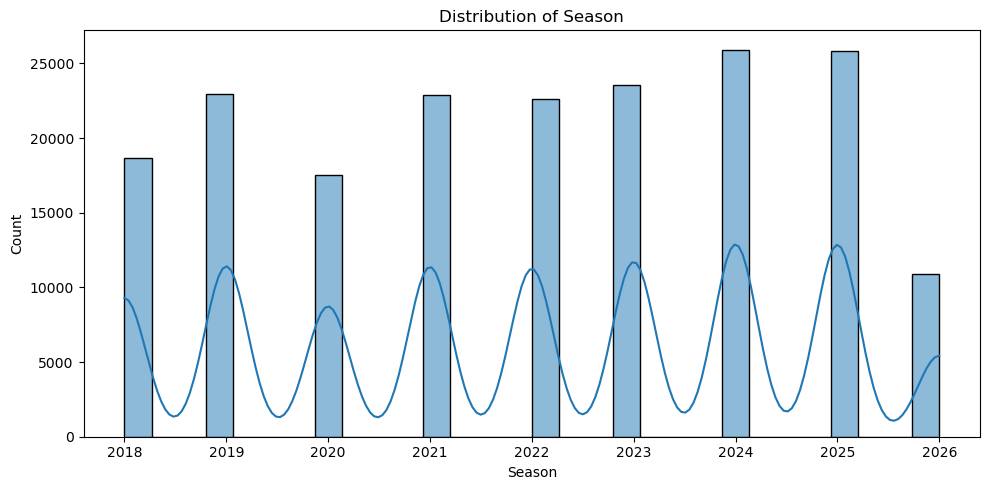

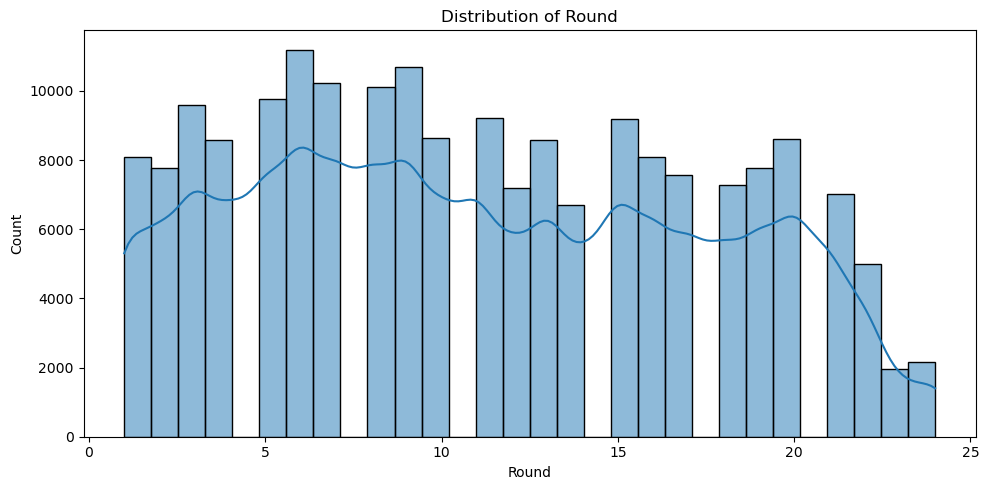

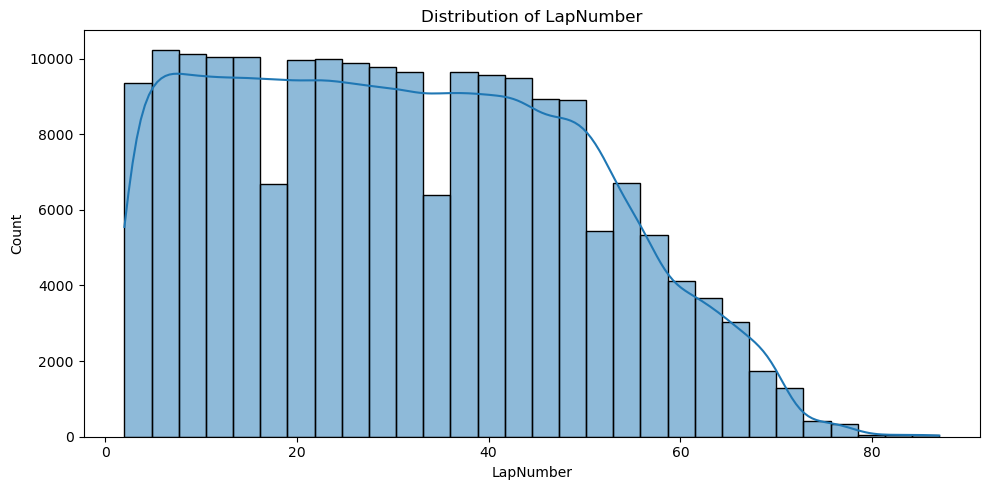

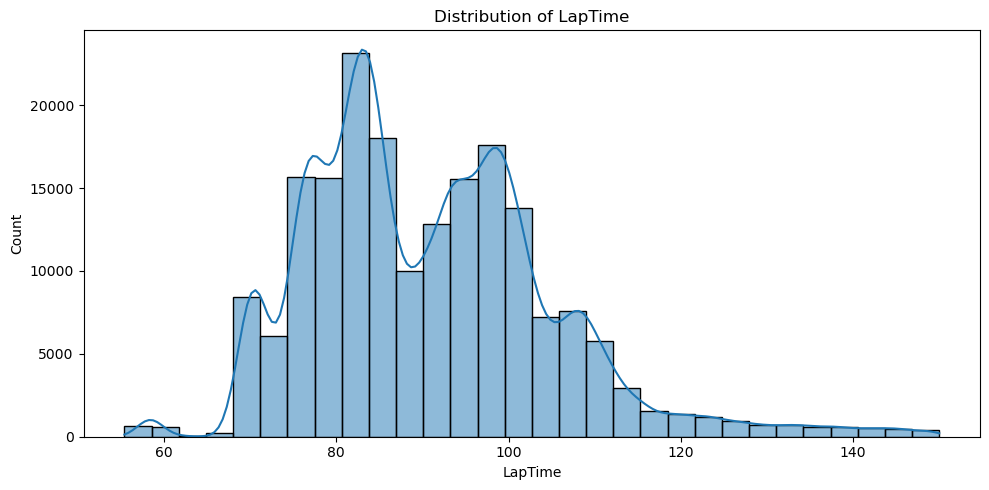

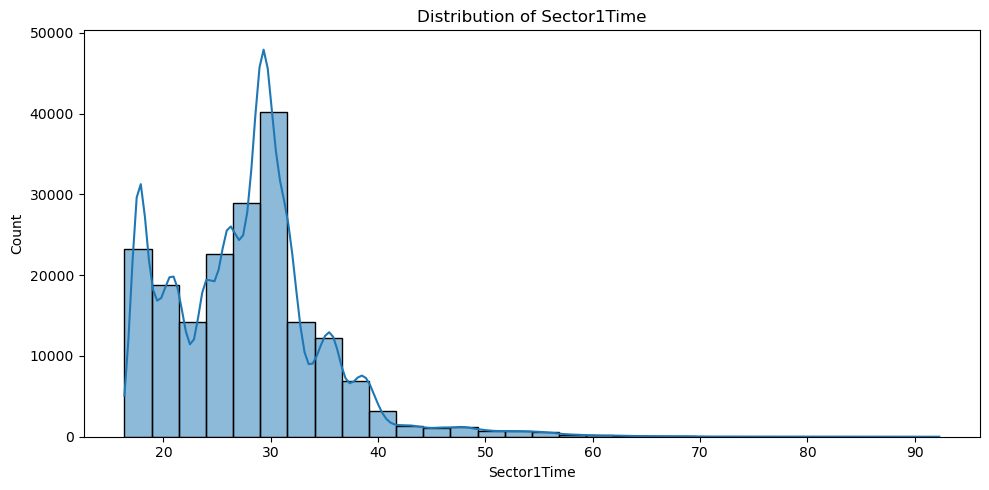

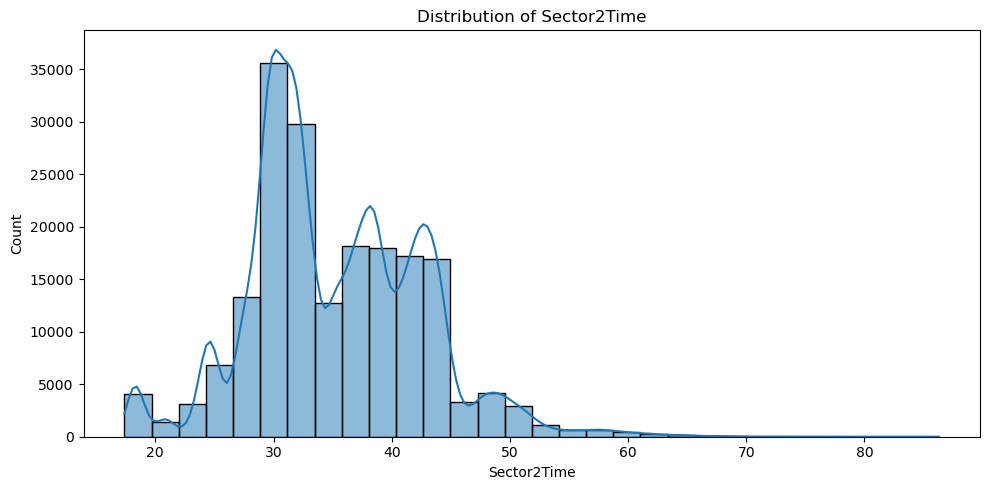

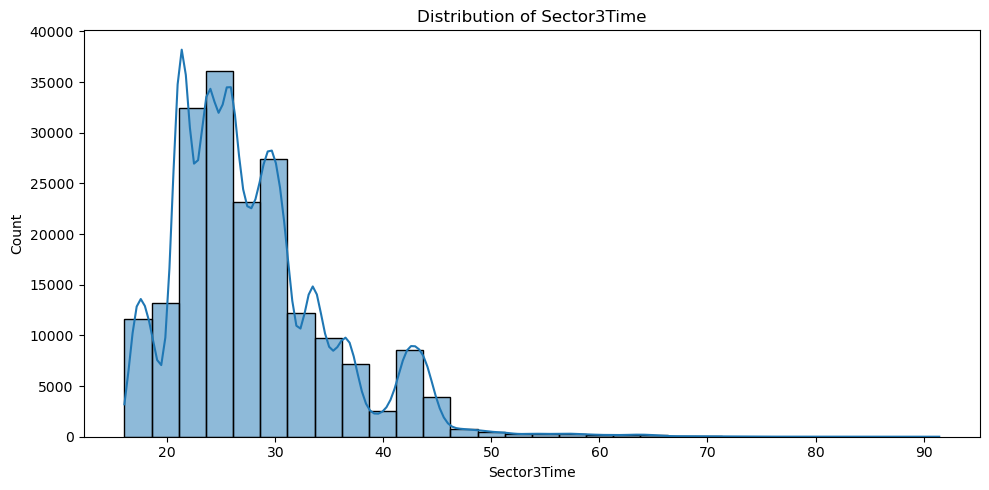

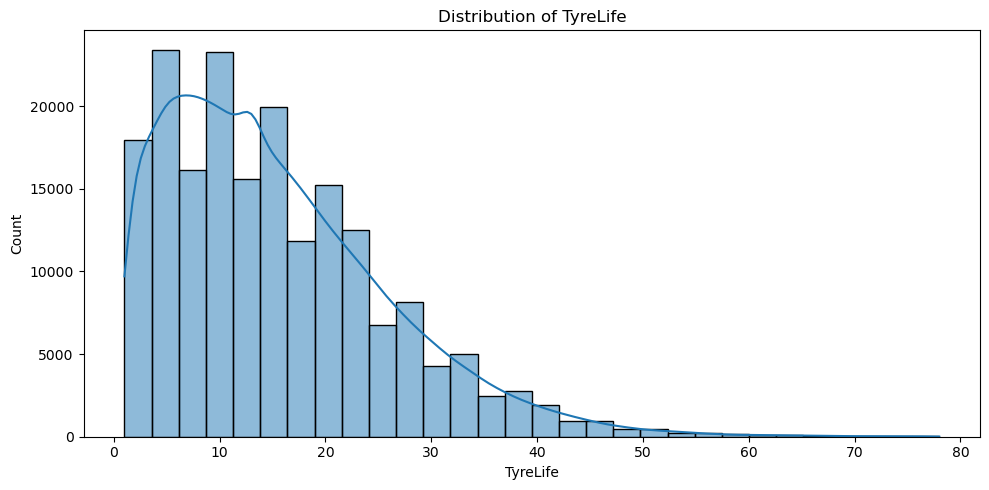

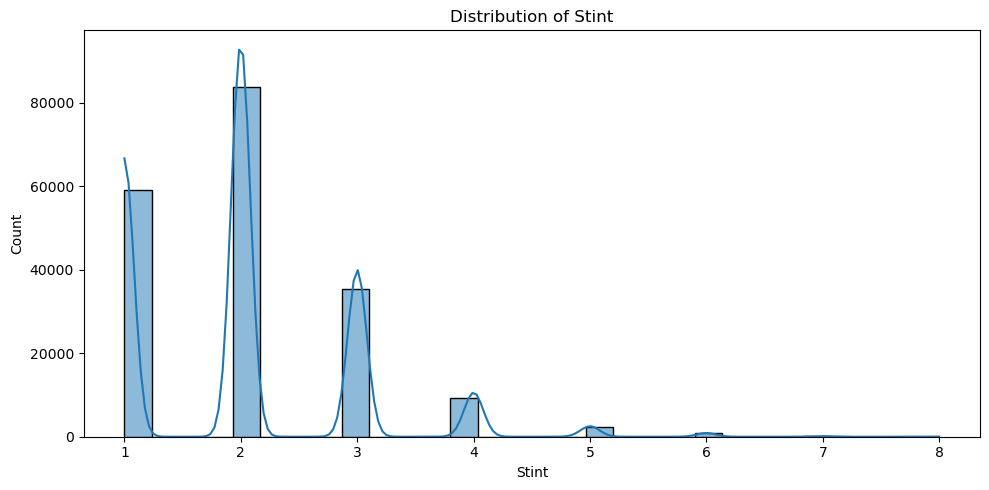

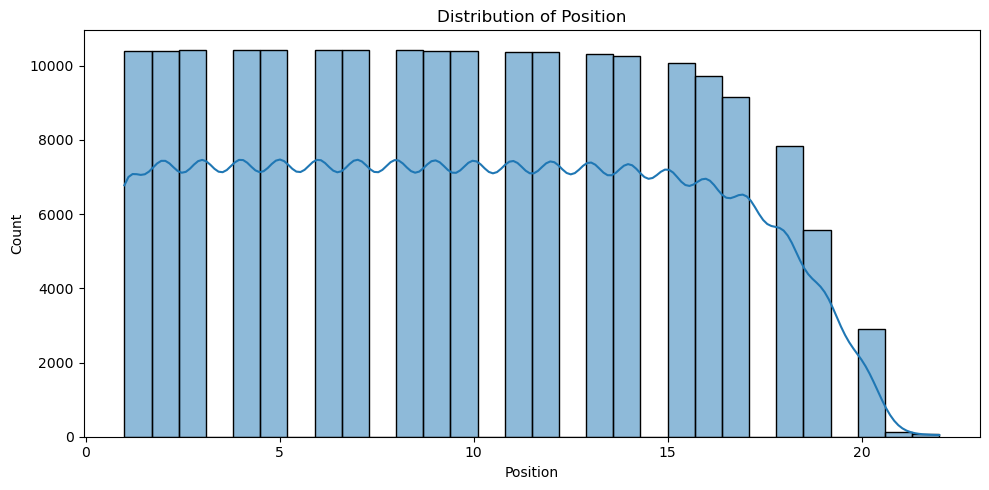

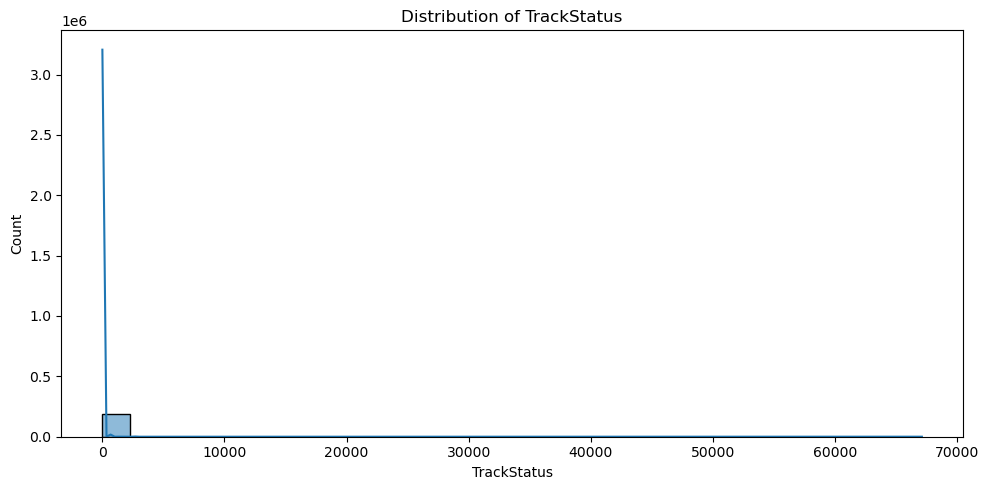

In [11]:
for col in numerical_cols:

    plt.figure(figsize=(10,5))

    sns.histplot(df[col], bins=30, kde=True)

    plt.title(f"Distribution of {col}")

    plt.tight_layout()

    plt.savefig(f"images/histograms/{col}_histogram.png", dpi=300)

    plt.show()

    plt.close()

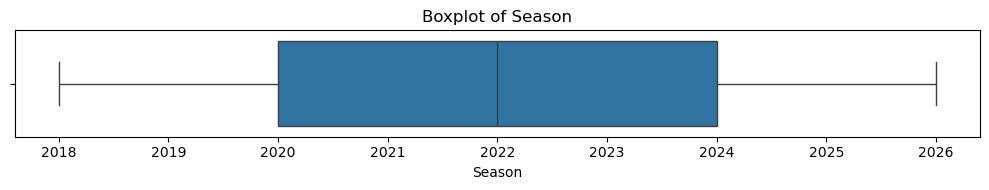

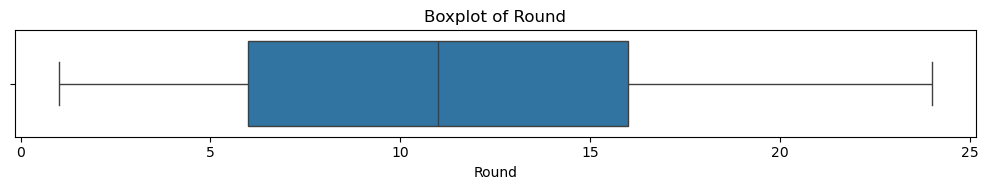

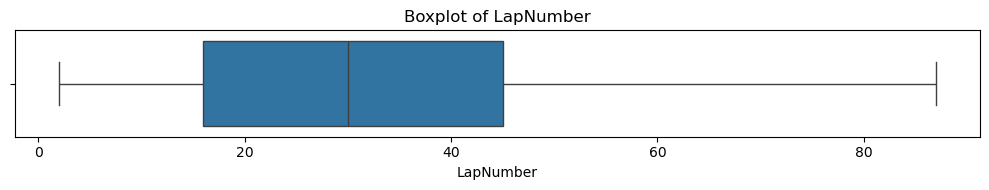

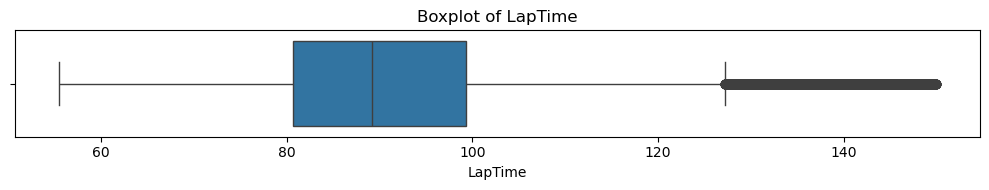

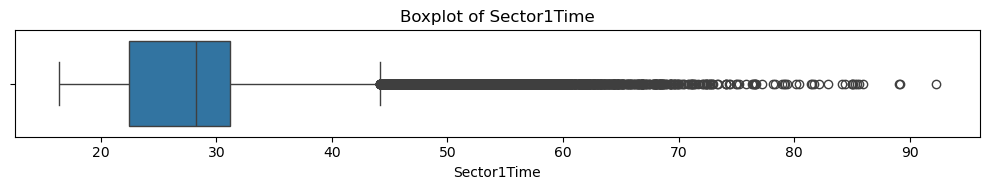

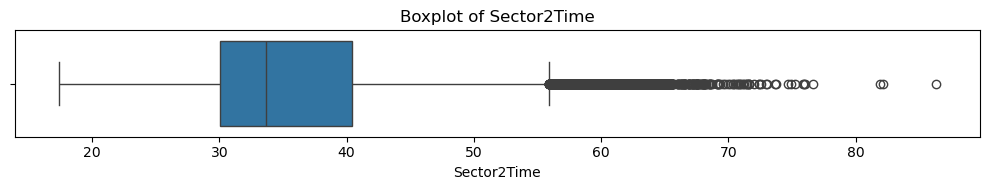

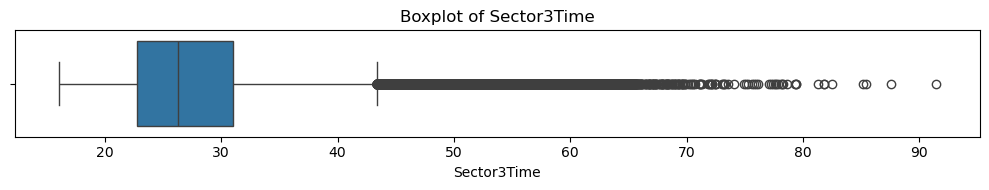

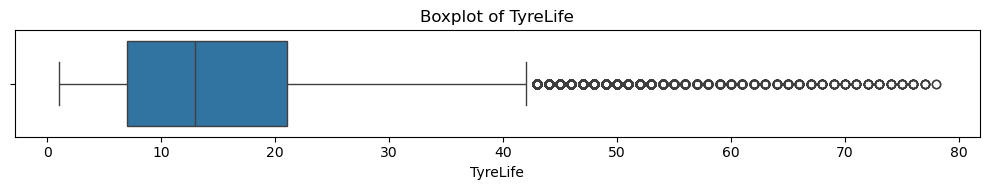

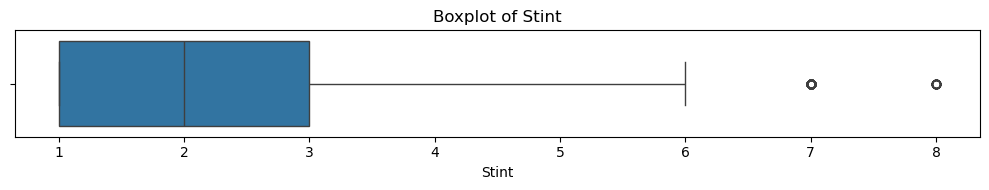

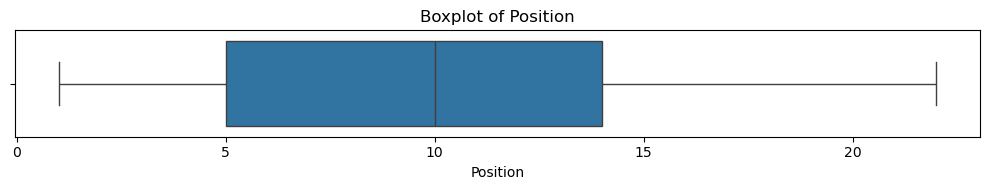

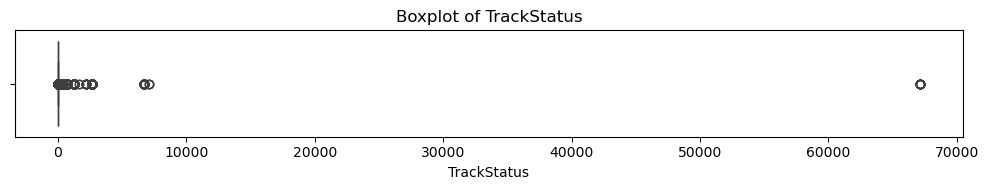

In [12]:
for col in numerical_cols:

    plt.figure(figsize=(10,2))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.tight_layout()

    plt.savefig(f"images/boxplots/{col}_boxplot.png", dpi=300)

    plt.show()

    plt.close()

In [14]:
# Average Lap Time by Driver
driver_avg = (
    df.groupby("Driver")["LapTime"]
      .mean()
      .sort_values()
)

driver_avg.head()

Driver
AIT    62.950430
FIT    79.799401
DEV    88.714164
PIA    89.524171
HAD    89.684697
Name: LapTime, dtype: float64

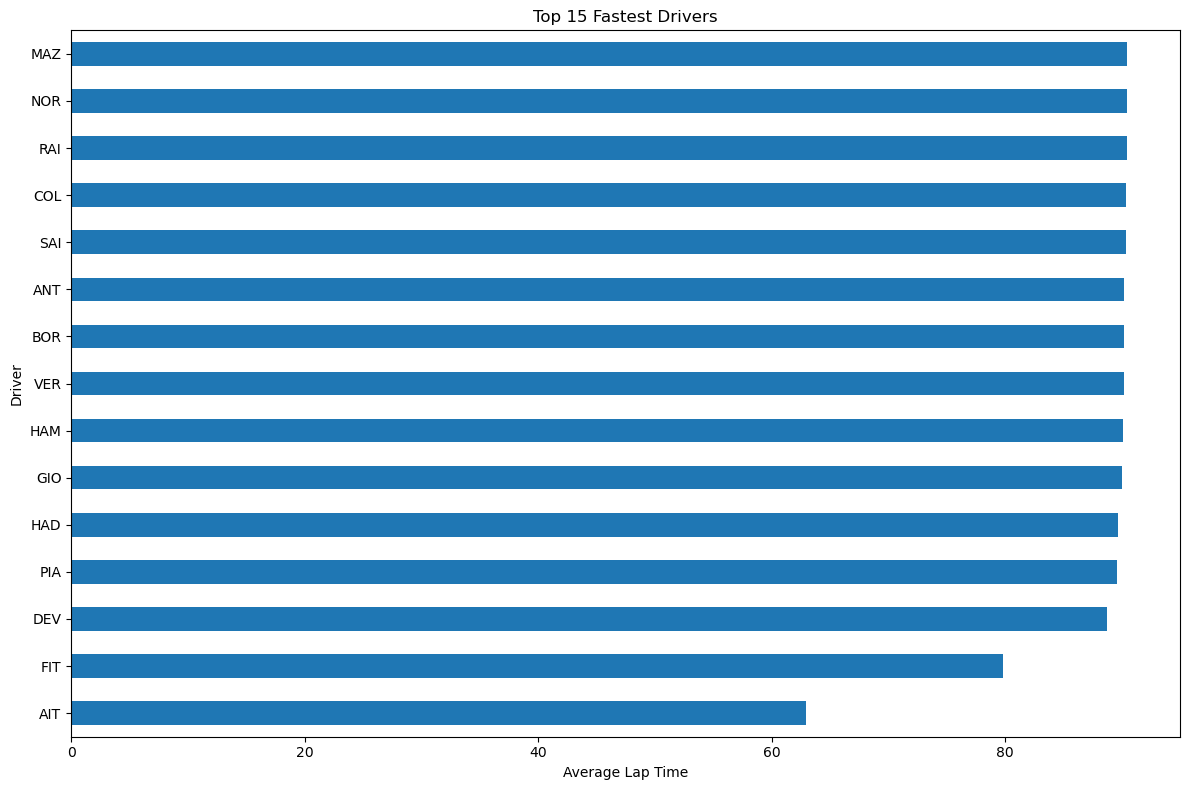

In [15]:
plt.figure(figsize=(12,8))

driver_avg.head(15).plot(kind="barh")

plt.title("Top 15 Fastest Drivers")

plt.xlabel("Average Lap Time")

plt.tight_layout()

plt.savefig(
    "images/driver_analysis/top15_fastest_drivers.png",
    dpi=300
)

plt.show()

plt.close()

In [16]:
team_avg = (
    df.groupby("Team")["LapTime"]
    .mean()
    .sort_values()
)

team_avg

Team
Force India          86.656655
Audi                 90.064224
Mercedes             90.087186
Alfa Romeo Racing    90.154779
Red Bull Racing      90.305663
Racing Bulls         90.391516
Ferrari              90.415532
McLaren              90.468103
AlphaTauri           90.806833
Alpine               90.868861
Kick Sauber          91.075539
RB                   91.075605
Renault              91.108976
Aston Martin         91.139289
Racing Point         91.221727
Haas F1 Team         91.708231
Williams             91.802897
Sauber               91.967440
Alfa Romeo           92.028329
Toro Rosso           92.287617
Cadillac             95.929228
Name: LapTime, dtype: float64

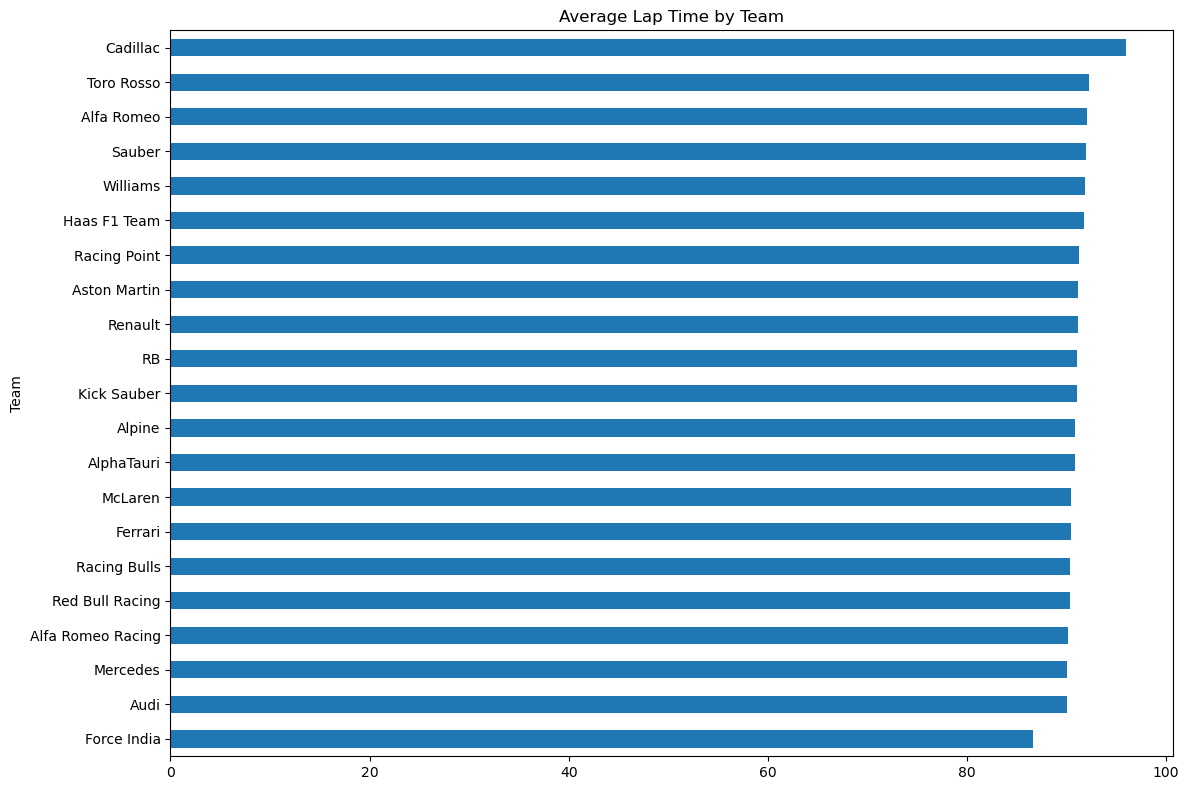

In [23]:
plt.figure(figsize=(12,8))

team_avg.plot(kind="barh")

plt.title("Average Lap Time by Team")

plt.tight_layout()

plt.savefig(
    "images/team_analysis/team_average_laptime.png",
    dpi=300
)

plt.show()

plt.close()

In [17]:
race_avg = (
    df.groupby("Race")["LapTime"]
    .mean()
    .sort_values()
)

race_avg

Race
Sakhir Grand Prix               62.873373
Styrian Grand Prix              71.043794
Austrian Grand Prix             72.573925
Brazilian Grand Prix            76.705660
Dutch Grand Prix                80.212709
Canadian Grand Prix             81.508294
São Paulo Grand Prix            81.566951
Monaco Grand Prix               81.586330
Mexican Grand Prix              84.186344
Hungarian Grand Prix            84.504062
Mexico City Grand Prix          85.055799
Portuguese Grand Prix           85.209181
Spanish Grand Prix              85.282308
Barcelona Grand Prix            85.917915
Emilia Romagna Grand Prix       86.825767
Italian Grand Prix              87.890013
German Grand Prix               89.882337
Australian Grand Prix           90.263629
Qatar Grand Prix                91.948426
Tuscan Grand Prix               92.367054
70th Anniversary Grand Prix     93.247355
Eifel Grand Prix                95.811440
Miami Grand Prix                96.238480
Abu Dhabi Grand Prix         

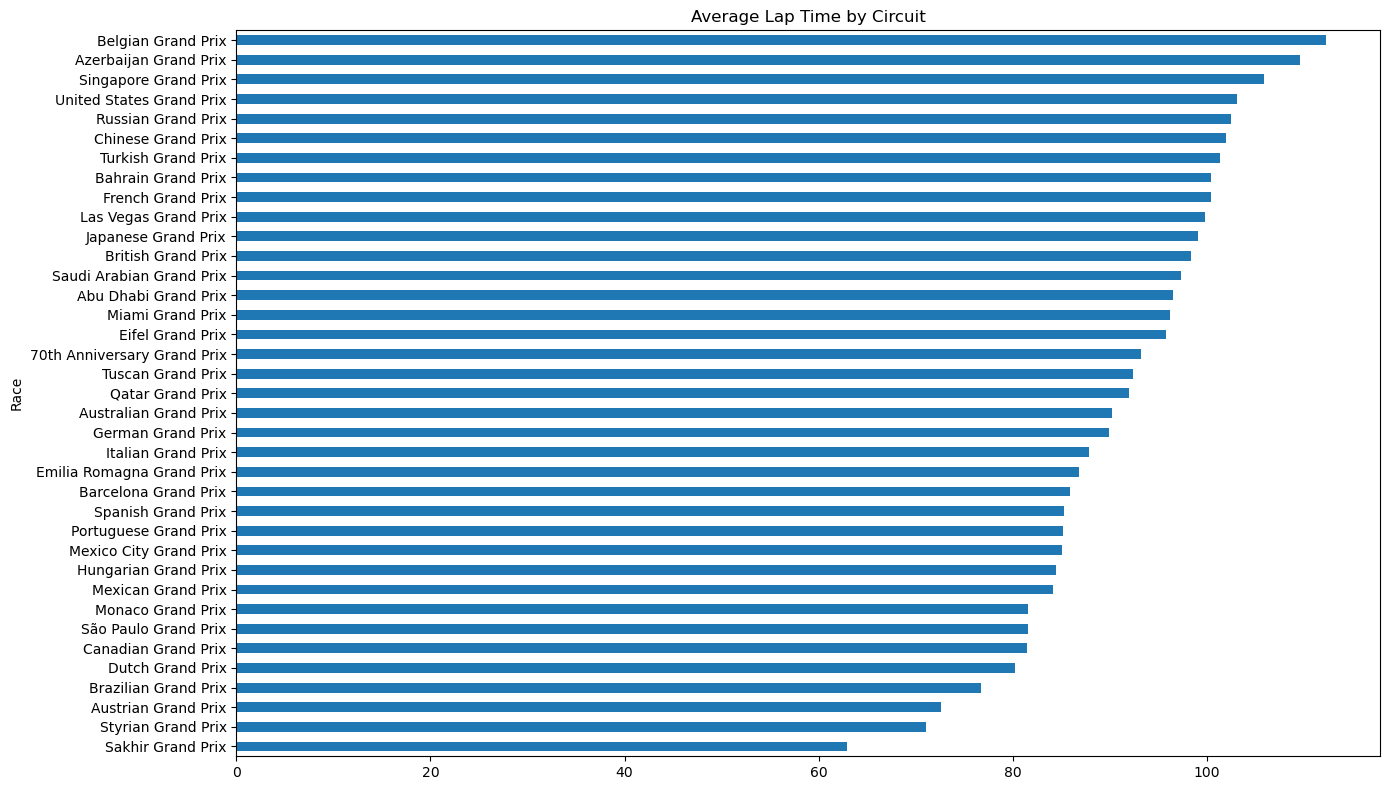

In [24]:
plt.figure(figsize=(14,8))

race_avg.plot(kind="barh")

plt.title("Average Lap Time by Circuit")

plt.tight_layout()

plt.savefig(
    "images/race_analysis/race_average_laptime.png",
    dpi=300
)

plt.show()

plt.close()

In [18]:
compound = (
    df["Compound"]
    .value_counts()
)

compound

Compound
HARD            72647
MEDIUM          66048
SOFT            32617
INTERMEDIATE     8752
SUPERSOFT        4855
ULTRASOFT        3753
HYPERSOFT         831
UNKNOWN           805
WET               606
Name: count, dtype: int64

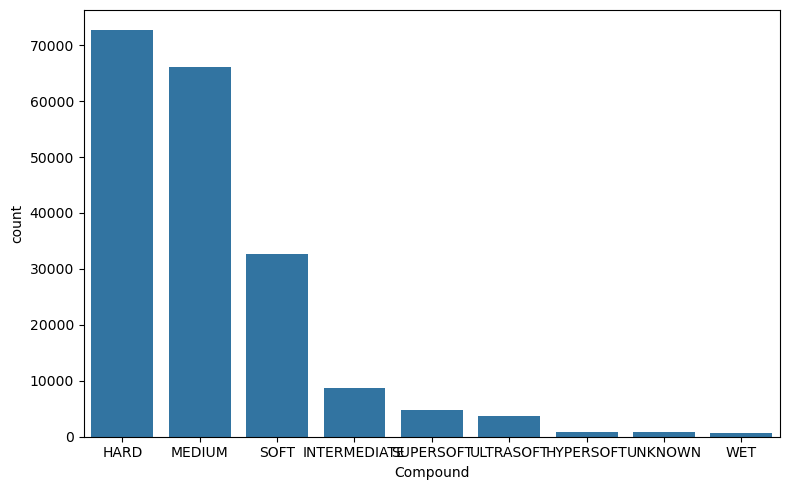

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Compound",
    order=df["Compound"].value_counts().index
)

plt.tight_layout()

plt.savefig(
    "images/tyre_analysis/compound_count.png",
    dpi=300
)

plt.show()

plt.close()

In [19]:
compound_avg = (
    df.groupby("Compound")["LapTime"]
    .mean()
)

compound_avg

Compound
HARD             90.521642
HYPERSOFT        92.033857
INTERMEDIATE    100.988597
MEDIUM           89.999867
SOFT             90.485248
SUPERSOFT        89.489354
ULTRASOFT        93.053705
UNKNOWN          86.713492
WET             108.057622
Name: LapTime, dtype: float64

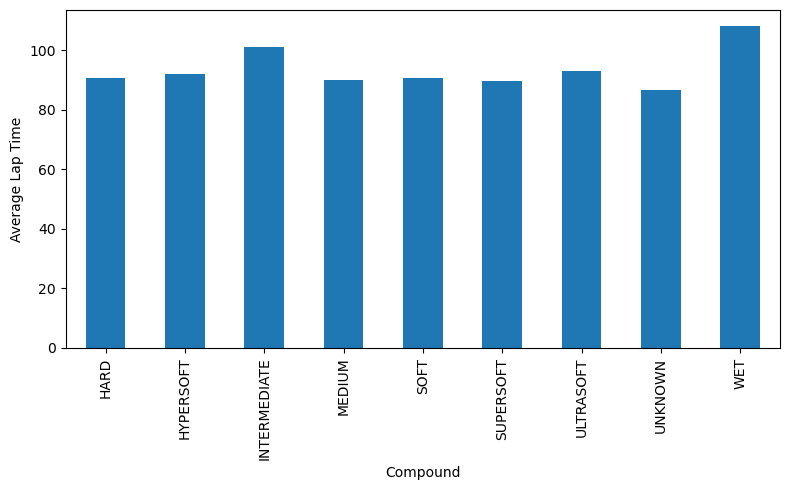

In [26]:
plt.figure(figsize=(8,5))

compound_avg.plot(kind="bar")

plt.ylabel("Average Lap Time")

plt.tight_layout()

plt.savefig(
    "images/tyre_analysis/compound_average_laptime.png",
    dpi=300
)

plt.show()

plt.close()

In [20]:
season_avg = (
    df.groupby("Season")["LapTime"]
    .mean()
)

season_avg

Season
2018    91.668743
2019    91.948444
2020    88.872107
2021    88.715969
2022    93.074582
2023    91.065983
2024    91.034776
2025    90.475041
2026    90.766141
Name: LapTime, dtype: float64

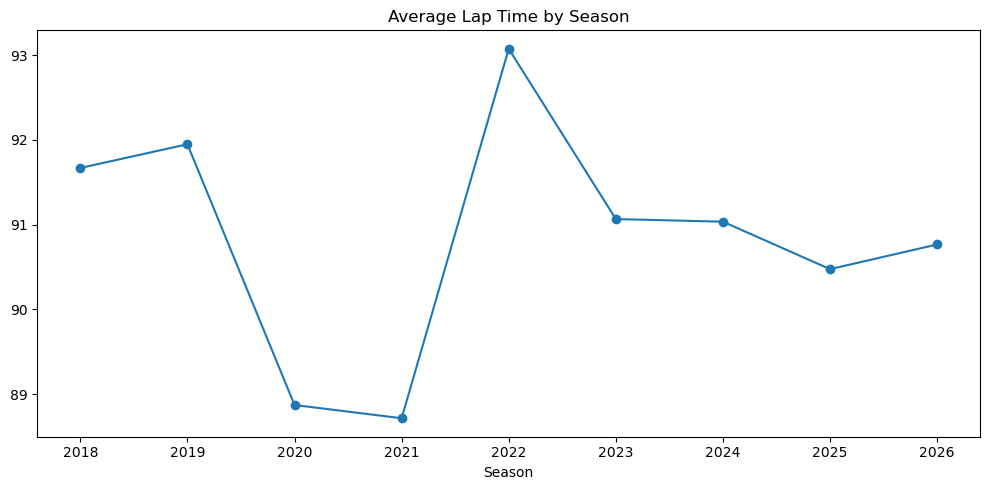

In [27]:
plt.figure(figsize=(10,5))

season_avg.plot(marker="o")

plt.title("Average Lap Time by Season")

plt.tight_layout()

plt.savefig(
    "images/season_analysis/season_average_laptime.png",
    dpi=300
)

plt.show()

plt.close()

In [21]:
position_avg = (
    df.groupby("Position")["LapTime"]
    .mean()
)

position_avg

Position
1.0      89.195315
2.0      89.446734
3.0      89.679666
4.0      90.003741
5.0      90.221525
6.0      90.455657
7.0      90.592529
8.0      90.691425
9.0      90.863862
10.0     91.042249
11.0     91.153582
12.0     91.226444
13.0     91.307792
14.0     91.518973
15.0     91.720784
16.0     91.681464
17.0     91.988667
18.0     92.183579
19.0     92.847538
20.0     92.004597
21.0     97.504952
22.0    100.109129
Name: LapTime, dtype: float64

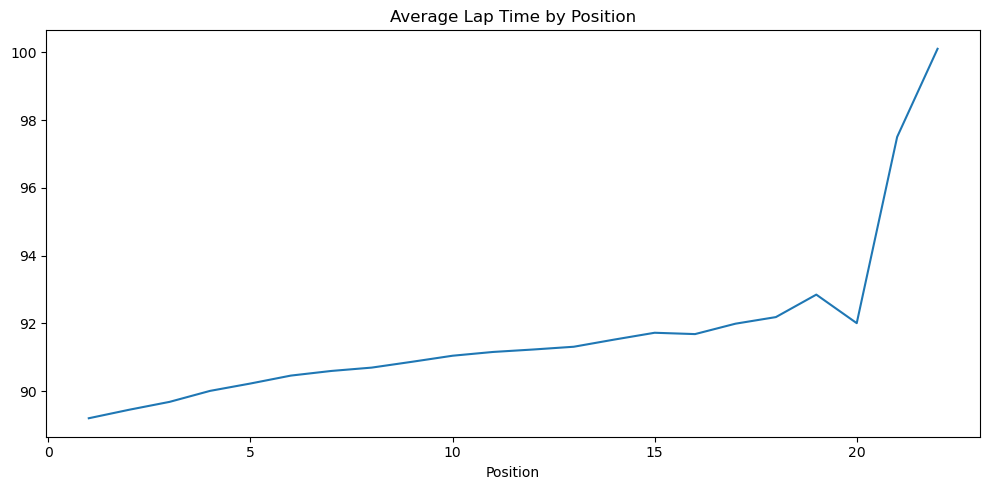

In [28]:
plt.figure(figsize=(10,5))

position_avg.plot()

plt.title("Average Lap Time by Position")

plt.tight_layout()

plt.savefig(
    "images/position_analysis/position_vs_laptime.png",
    dpi=300
)

plt.show()

plt.close()

In [22]:
corr = df.corr(numeric_only=True)

corr

,Season,Round,LapNumber,LapTime,Sector1Time,Sector2Time,Sector3Time,TyreLife,Stint,Position,TrackStatus
Season,1.000000,-0.008348,-0.007587,-0.005525,0.066051,-0.040565,-0.034267,-0.069412,0.053763,0.013123,-0.013303
Round,-0.008348,1.000000,0.004795,0.029531,-0.070977,0.194850,-0.068843,-0.022706,-0.027239,-0.003167,0.004222
LapNumber,-0.007587,0.004795,1.000000,-0.243342,-0.181398,-0.141127,-0.154547,0.493149,0.620346,-0.064202,-0.003316
LapTime,-0.005525,0.029531,-0.243342,1.000000,0.715708,0.648949,0.594900,-0.207427,-0.061648,0.062950,0.043666
Sector1Time,0.066051,-0.070977,-0.181398,0.715708,1.000000,0.261765,0.154921,-0.206818,0.007979,0.057431,0.038723
Sector2Time,-0.040565,0.194850,-0.141127,0.648949,0.261765,1.000000,0.003455,-0.128312,-0.036848,0.042139,0.020510
Sector3Time,-0.034267,-0.068843,-0.154547,0.594900,0.154921,0.003455,1.000000,-0.073015,-0.090446,0.024139,0.026557
TyreLife,-0.069412,-0.022706,0.493149,-0.207427,-0.206818,-0.128312,-0.073015,1.000000,-0.049232,-0.150196,-0.013287
Stint,0.053763,-0.027239,0.620346,-0.061648,0.007979,-0.036848,-0.090446,-0.049232,1.000000,0.090792,0.005749
Position,0.013123,-0.003167,-0.064202,0.062950,0.057431,0.042139,0.024139,-0.150196,0.090792,1.000000,-0.001880


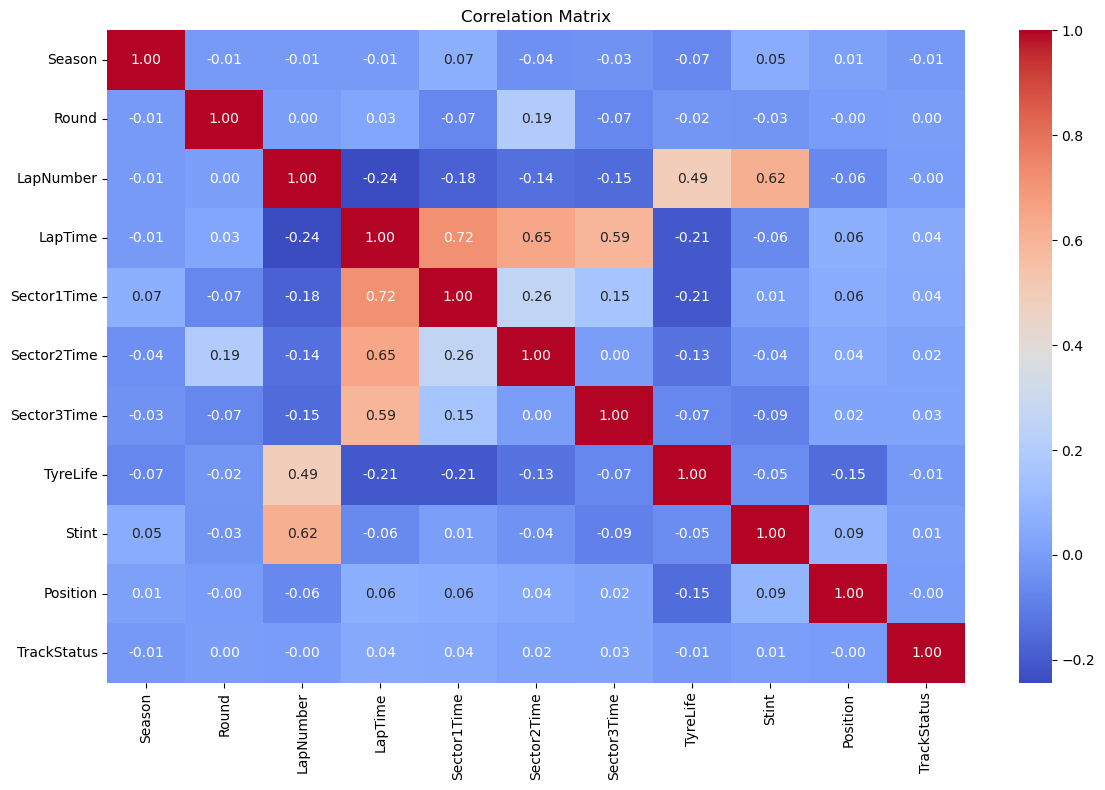

In [29]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "images/correlation/correlation_heatmap.png",
    dpi=300
)

plt.show()

plt.close()

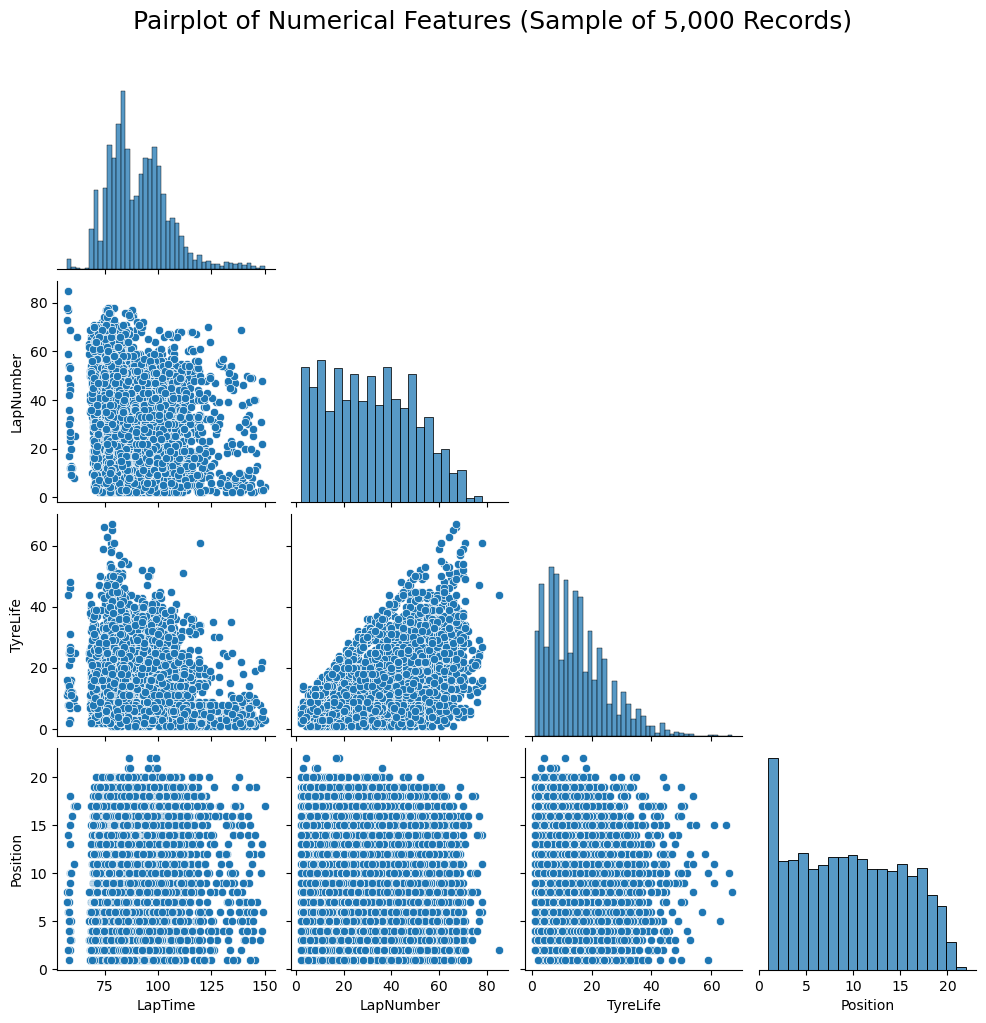

In [8]:
sample_df = df.sample(5000, random_state=42)

pair = sns.pairplot(
    sample_df[
        [
            "LapTime",
            "LapNumber",
            "TyreLife",
            "Position"
        ]
    ],
    diag_kind="hist",
    corner=True
)

pair.fig.suptitle(
    "Pairplot of Numerical Features (Sample of 5,000 Records)",
    fontsize=18,
    y=1.02
)

pair.savefig(
    "images/pairplot/pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

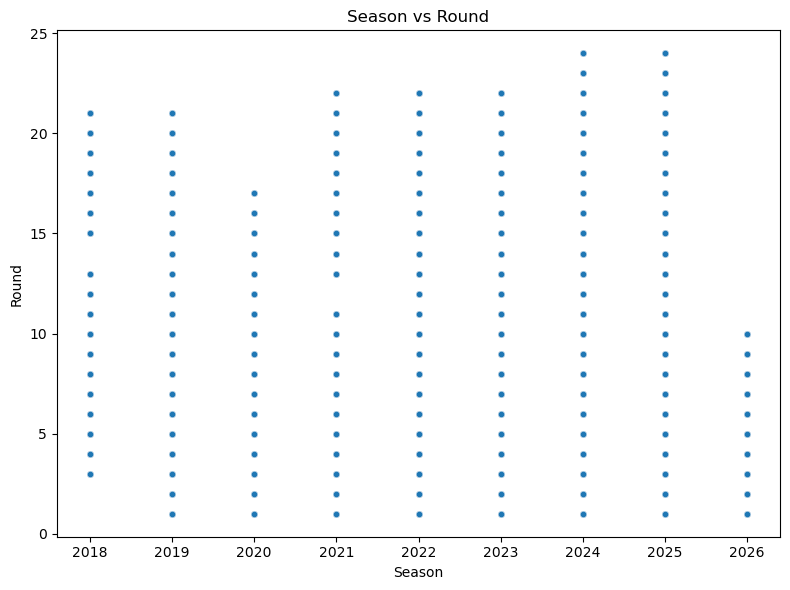

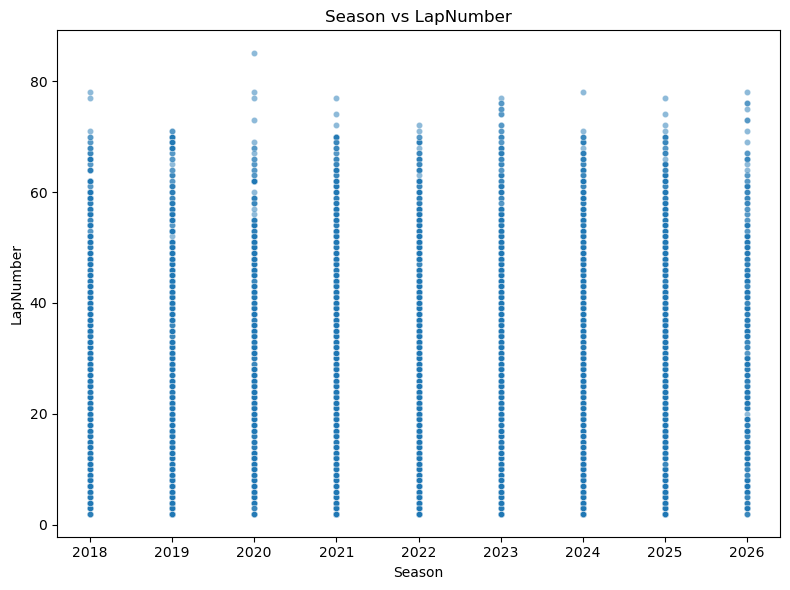

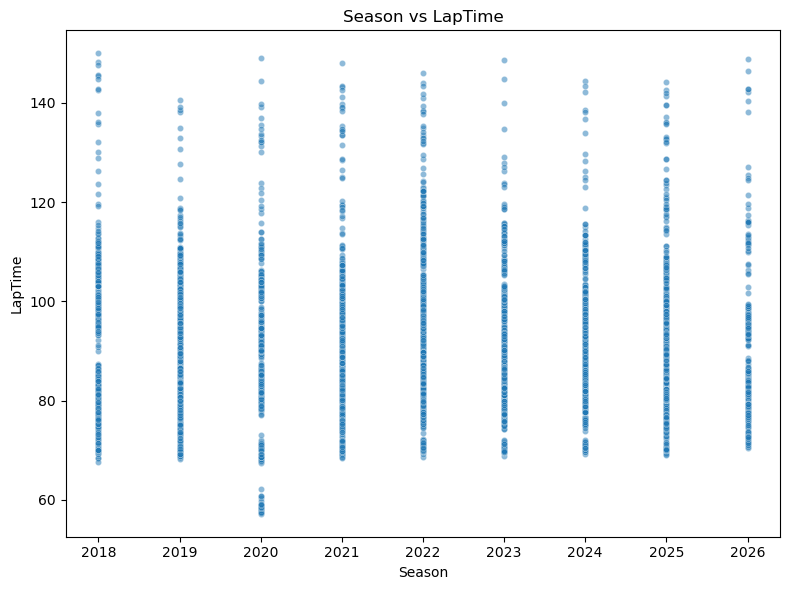

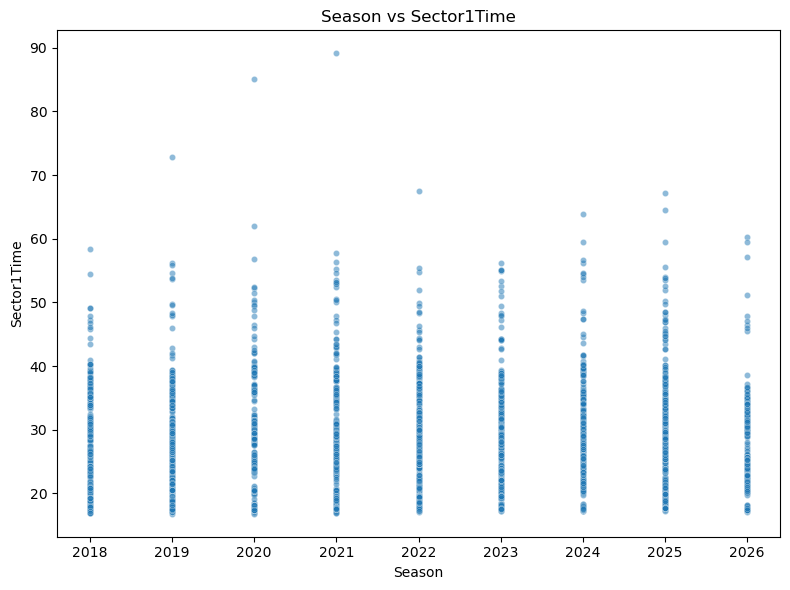

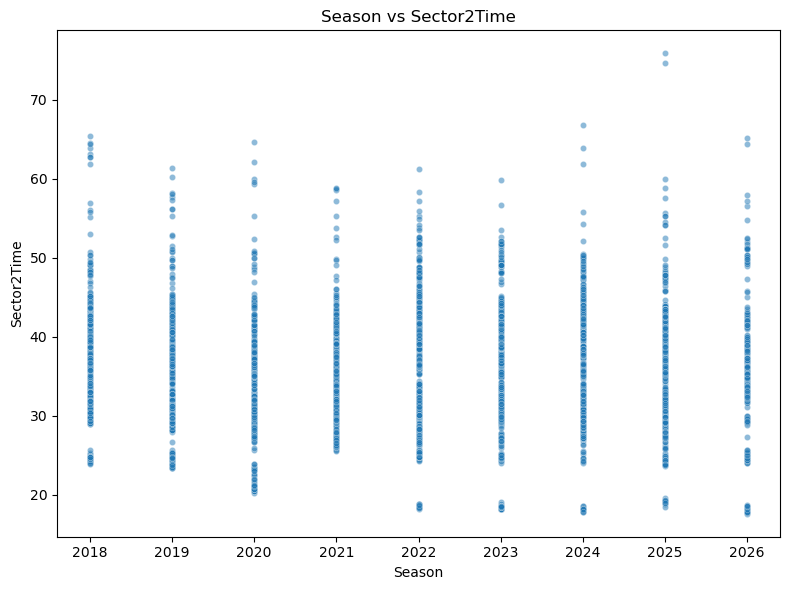

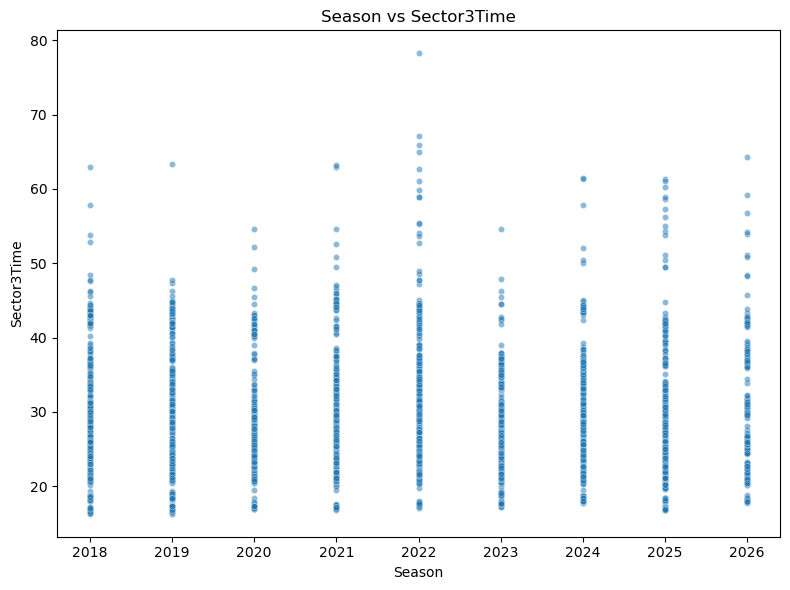

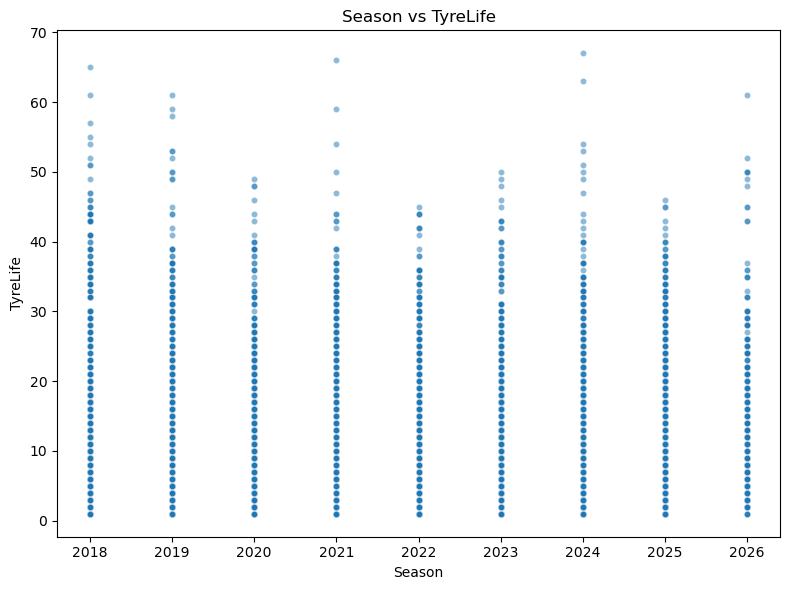

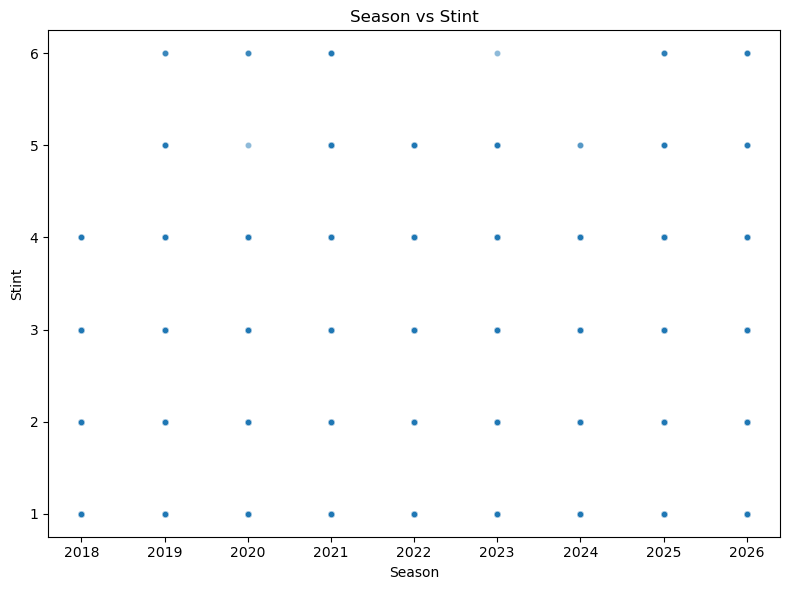

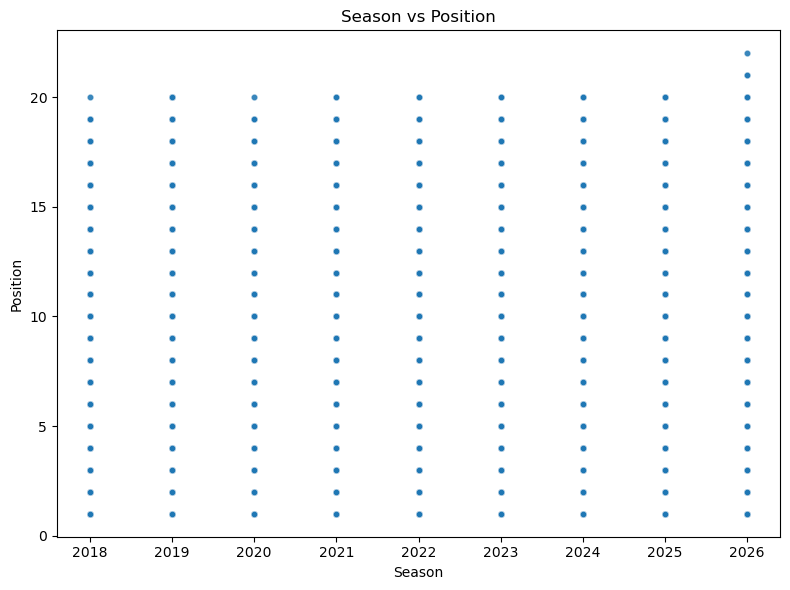

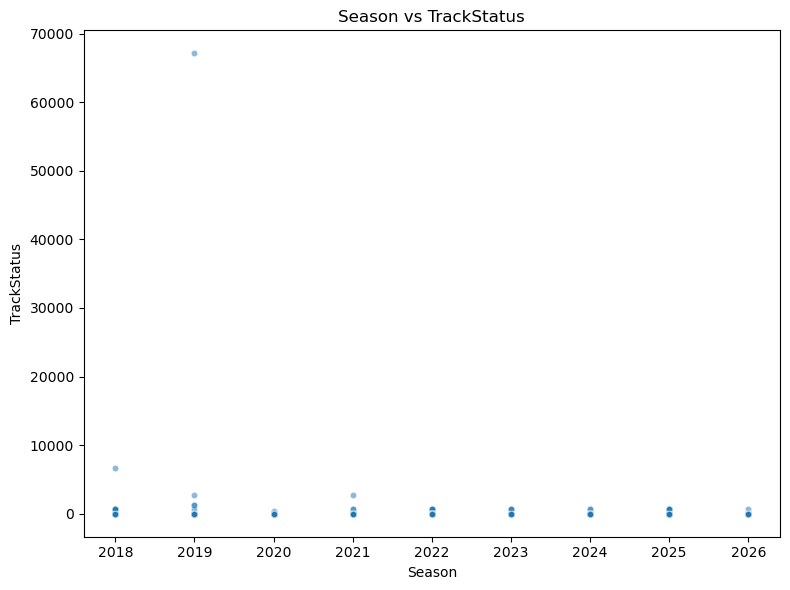

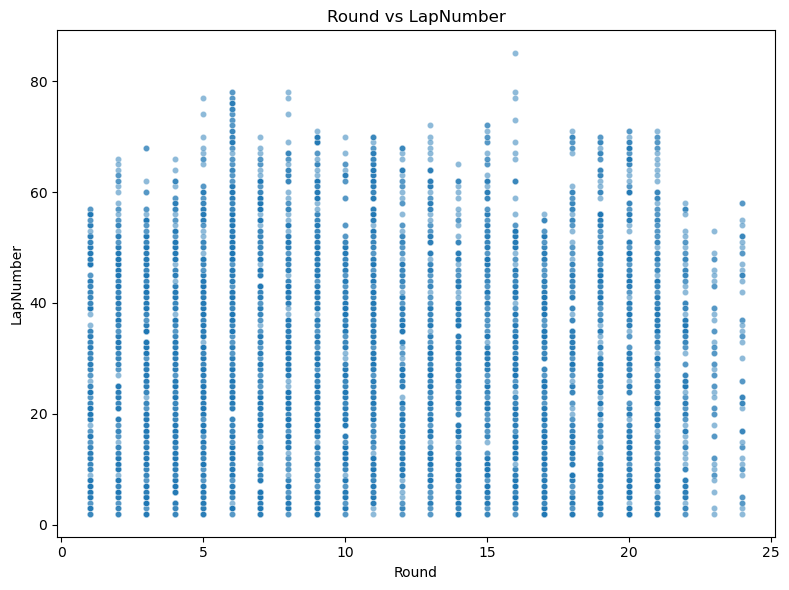

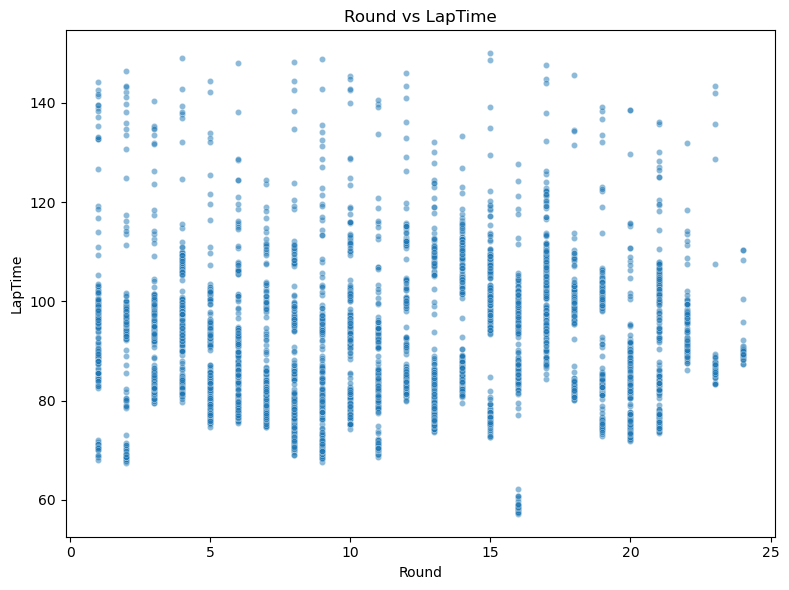

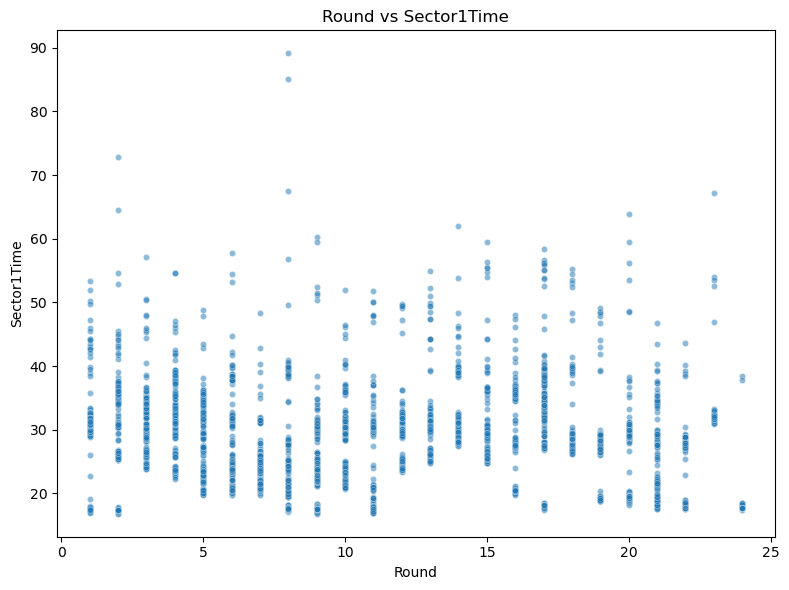

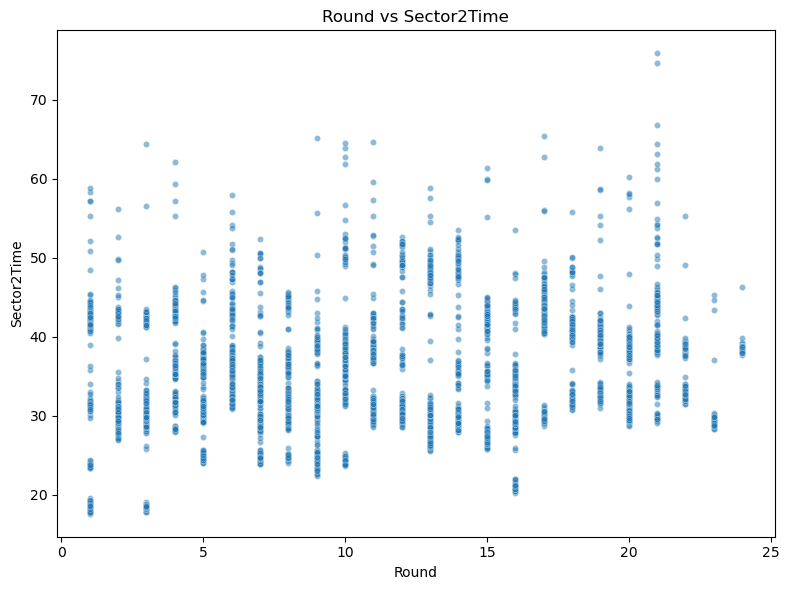

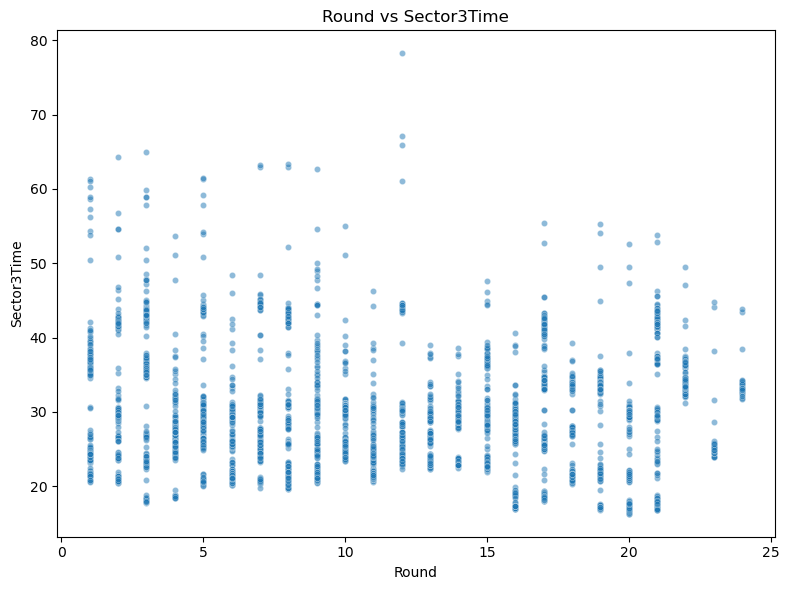

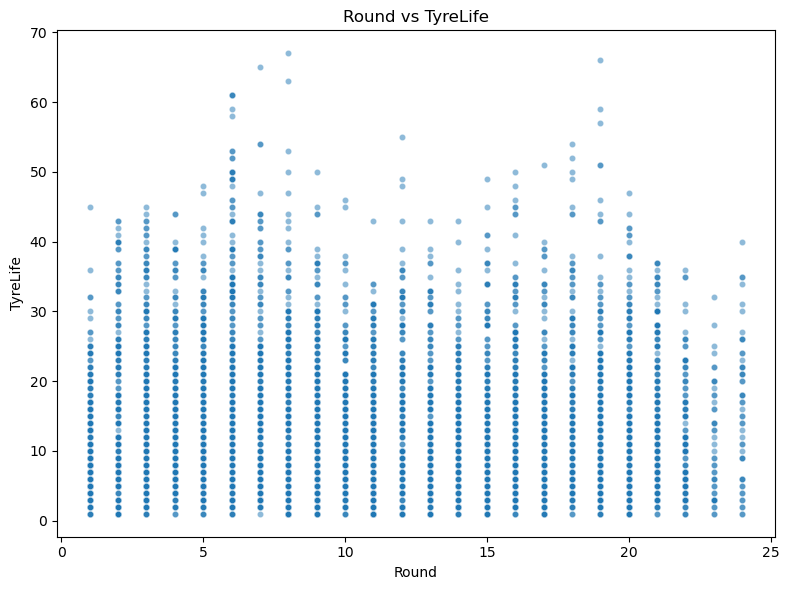

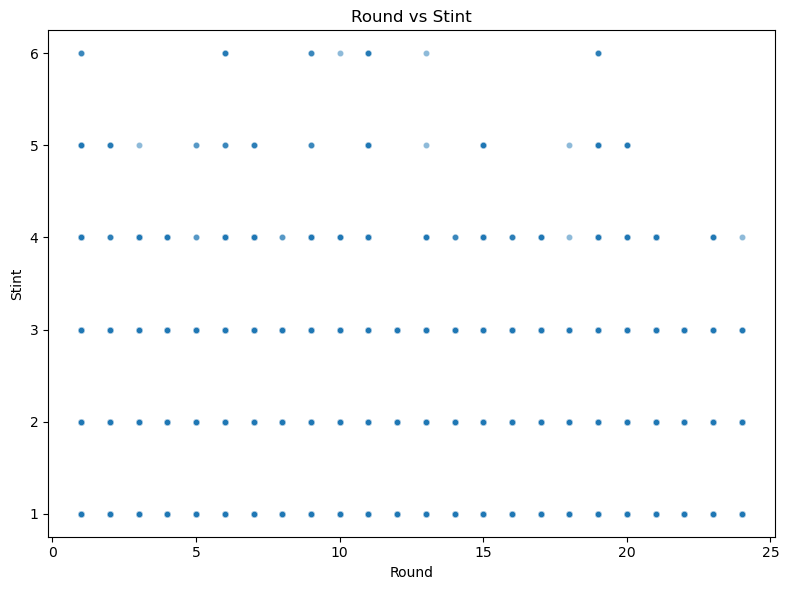

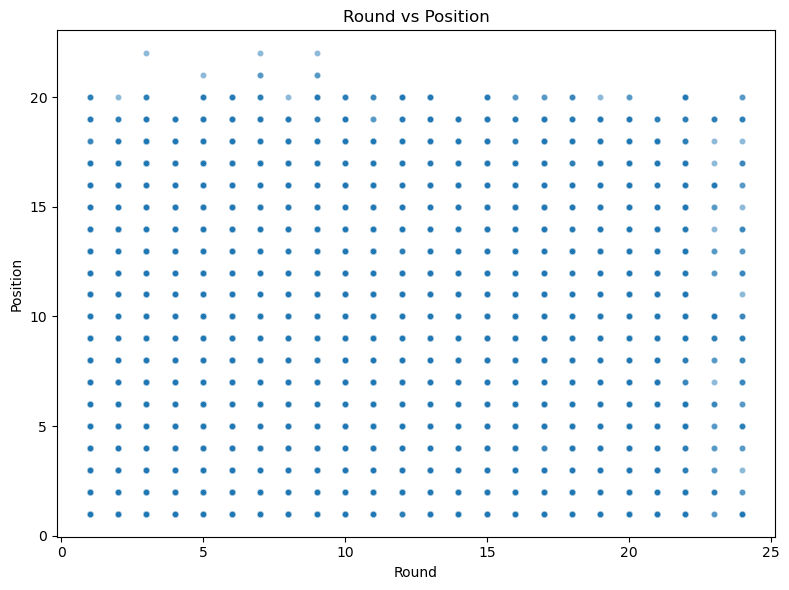

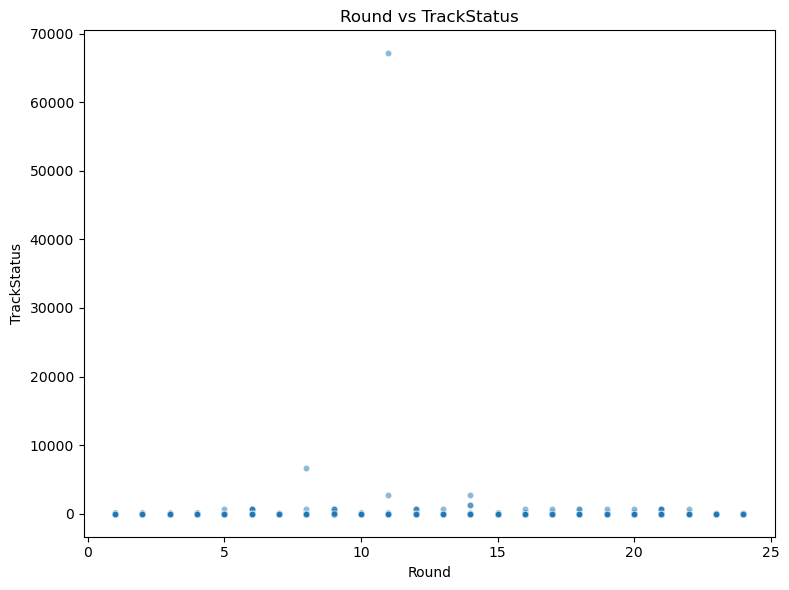

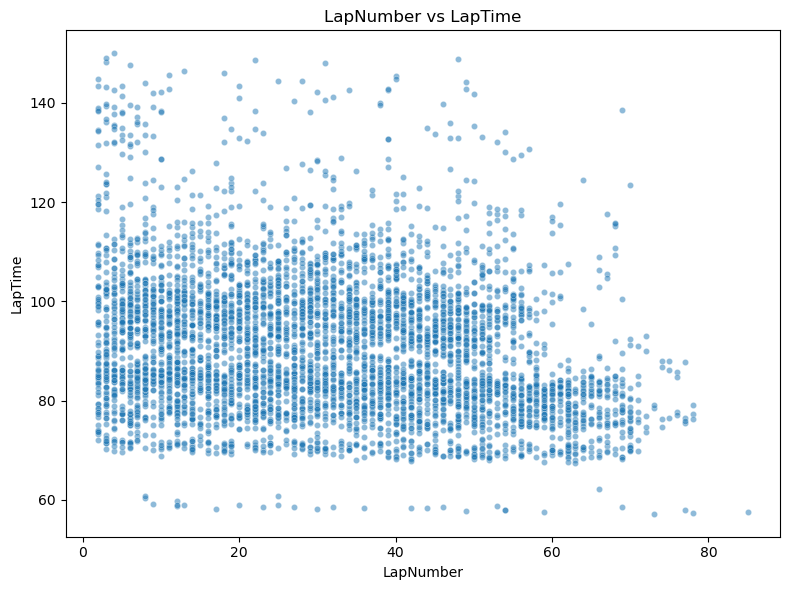

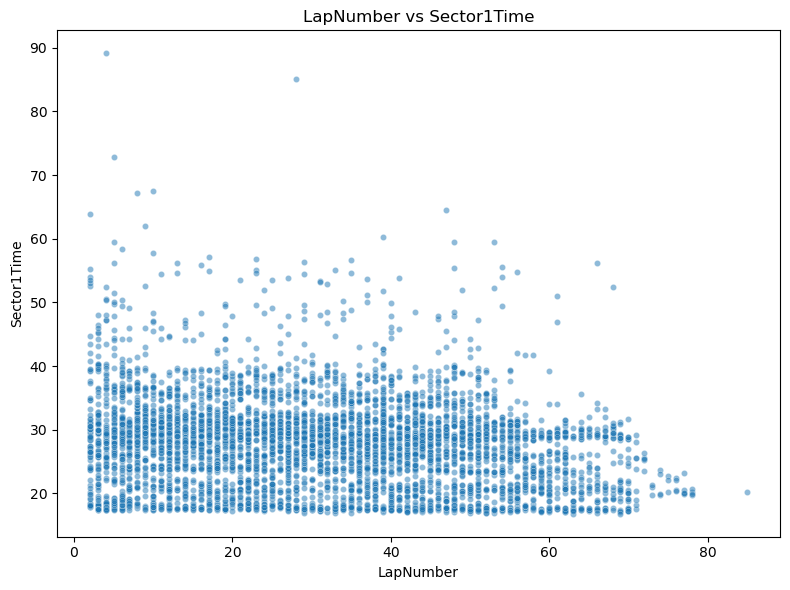

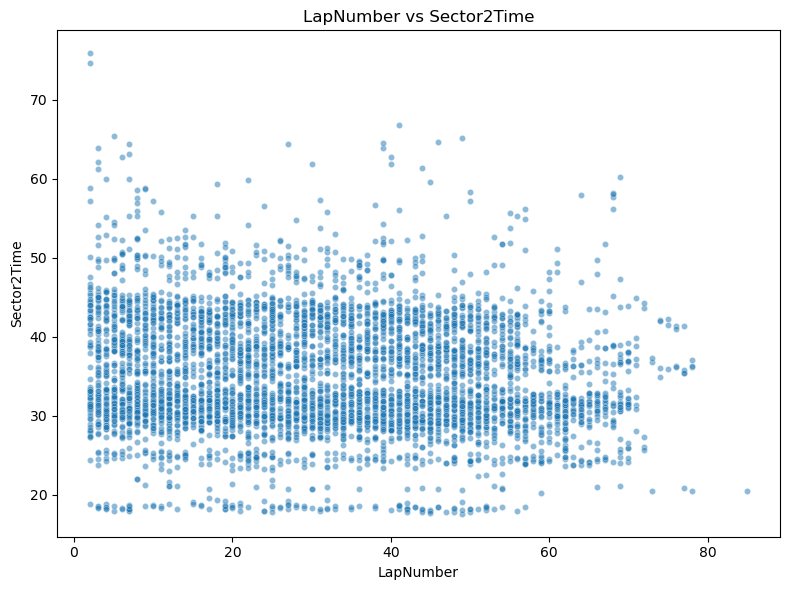

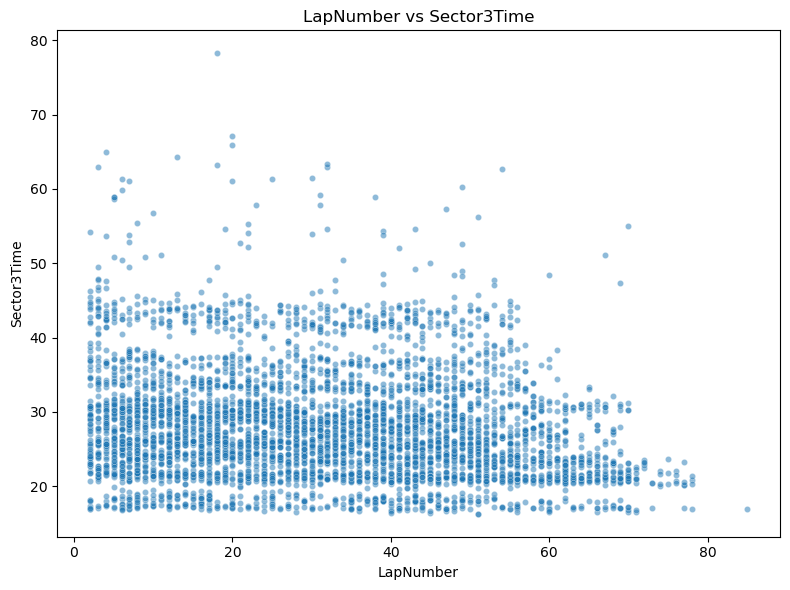

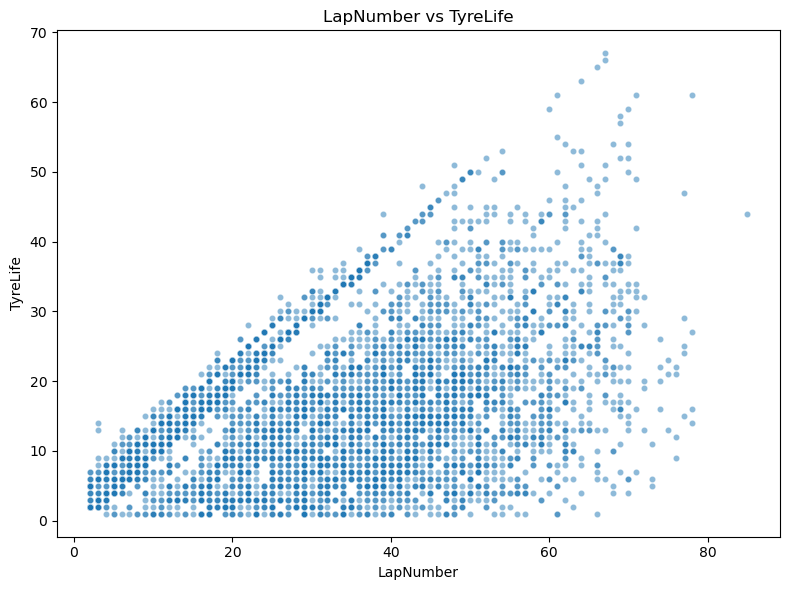

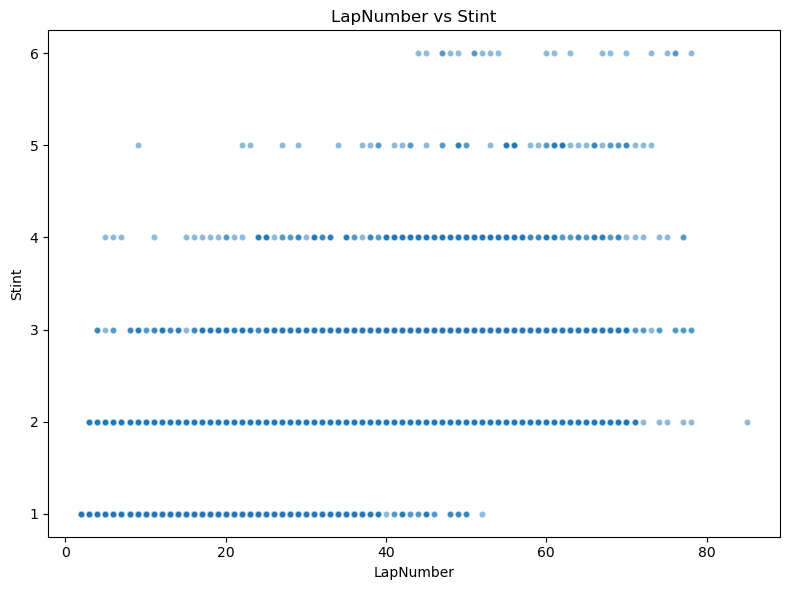

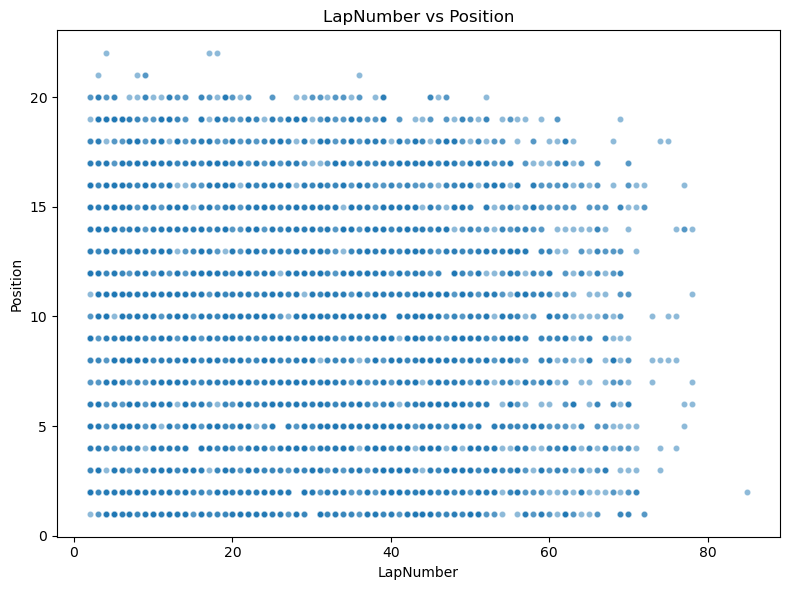

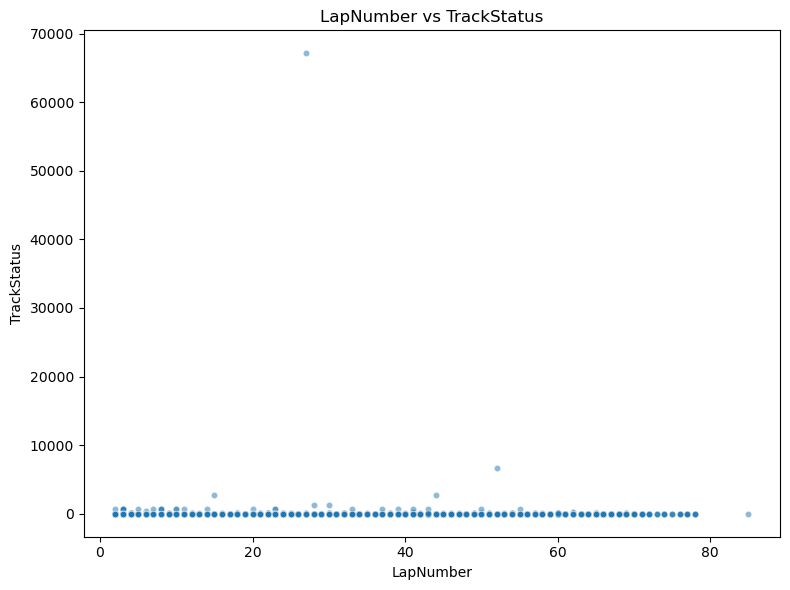

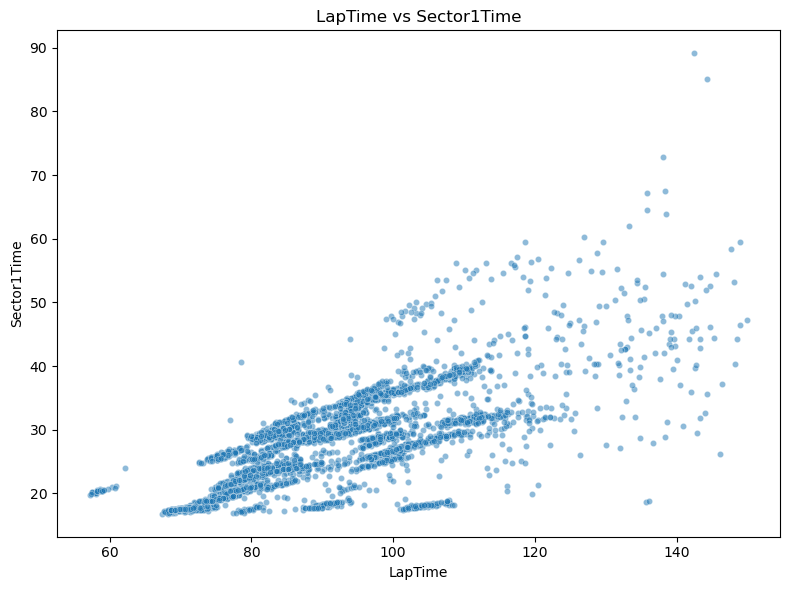

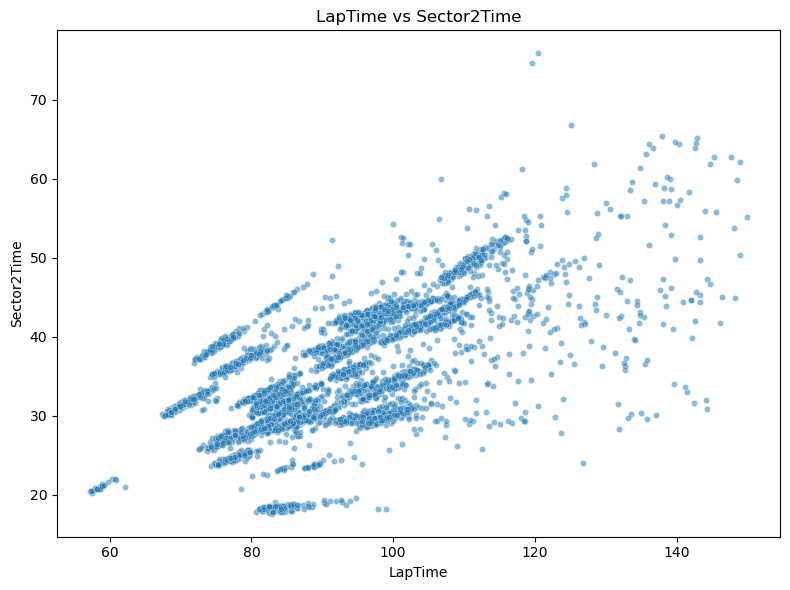

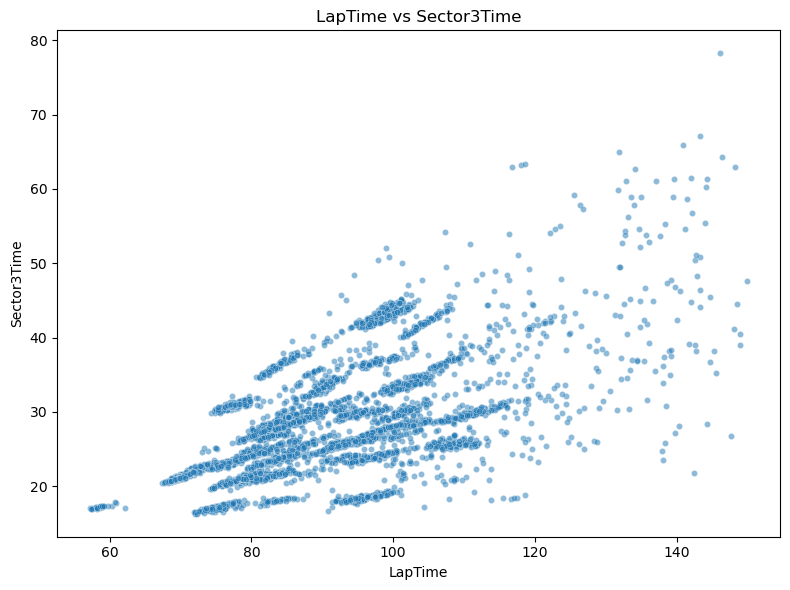

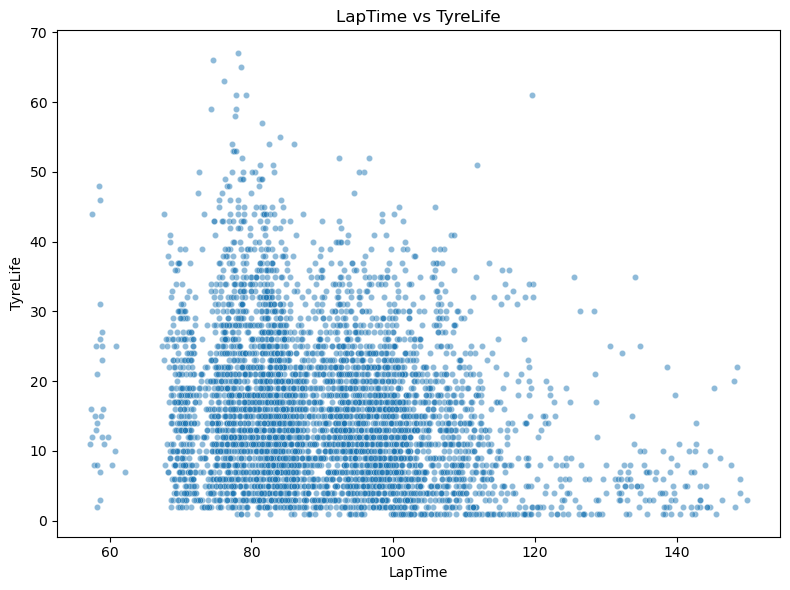

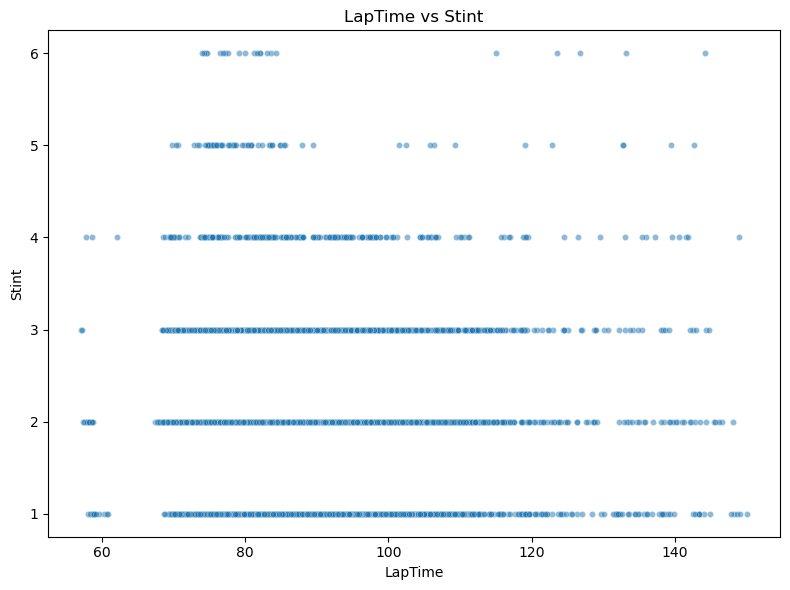

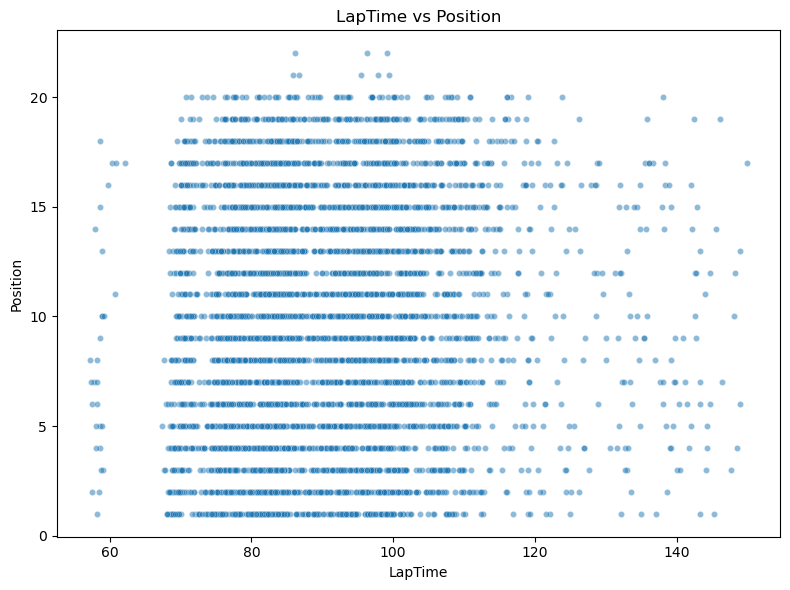

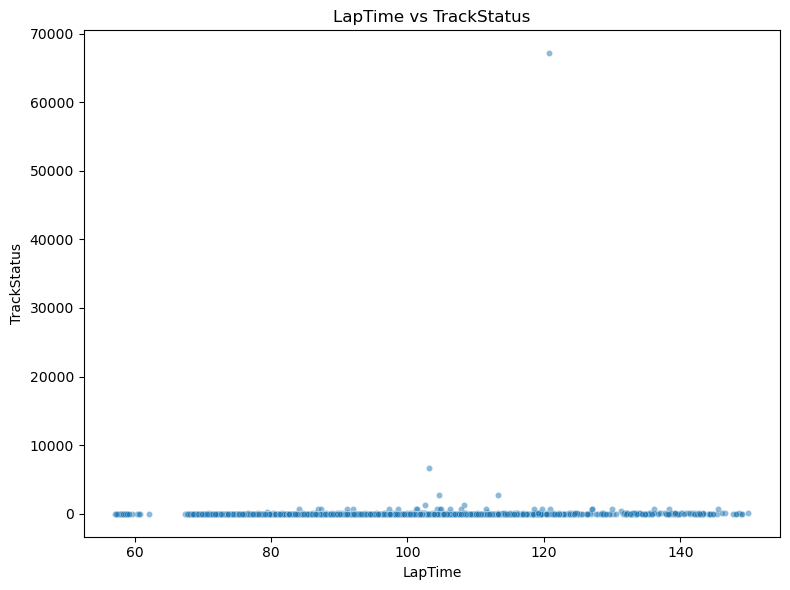

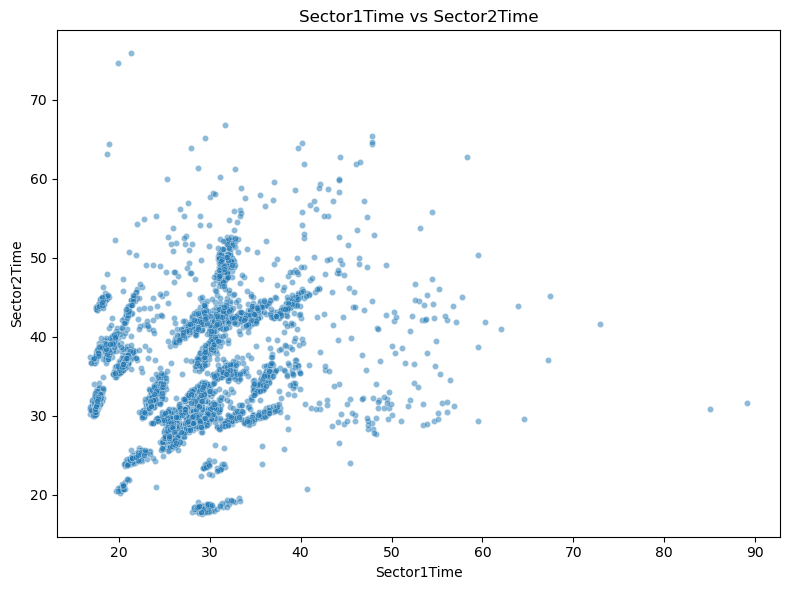

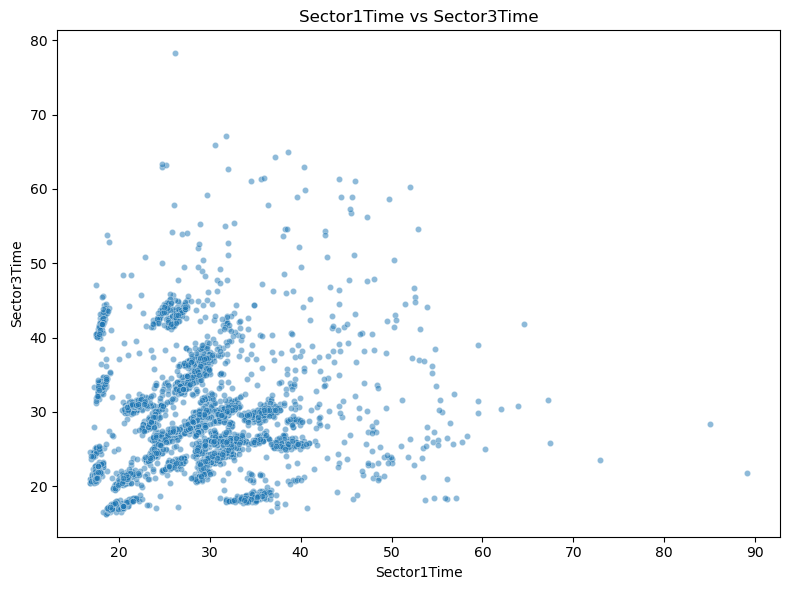

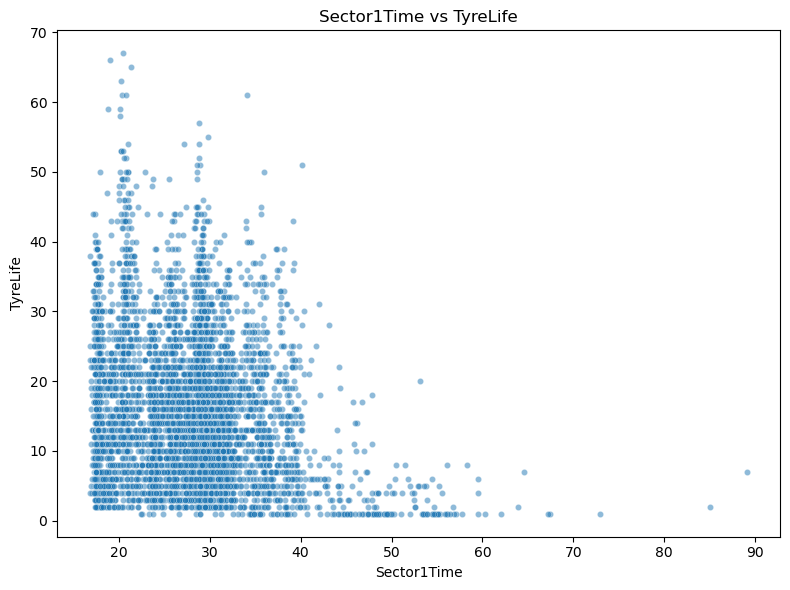

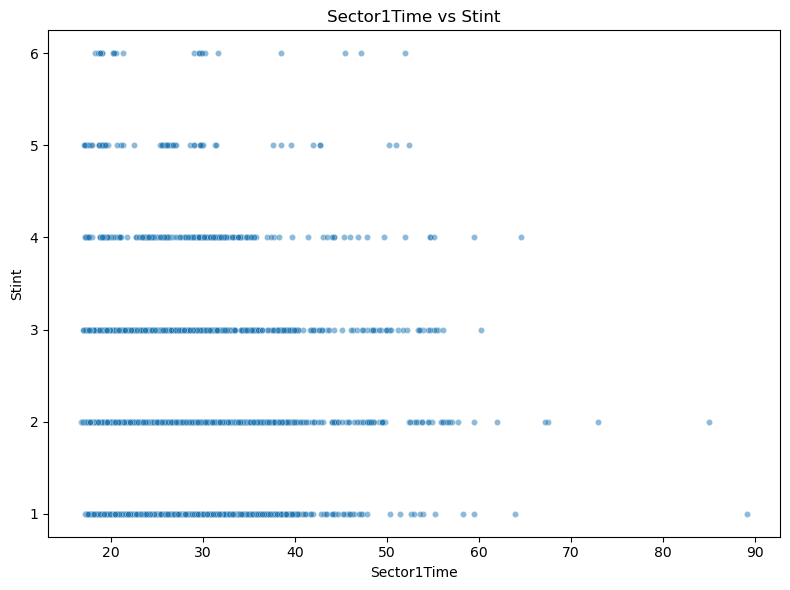

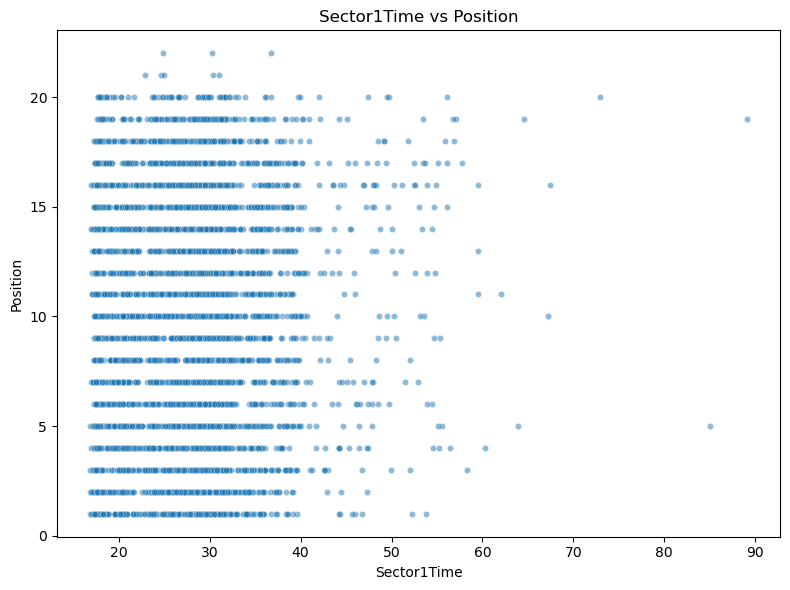

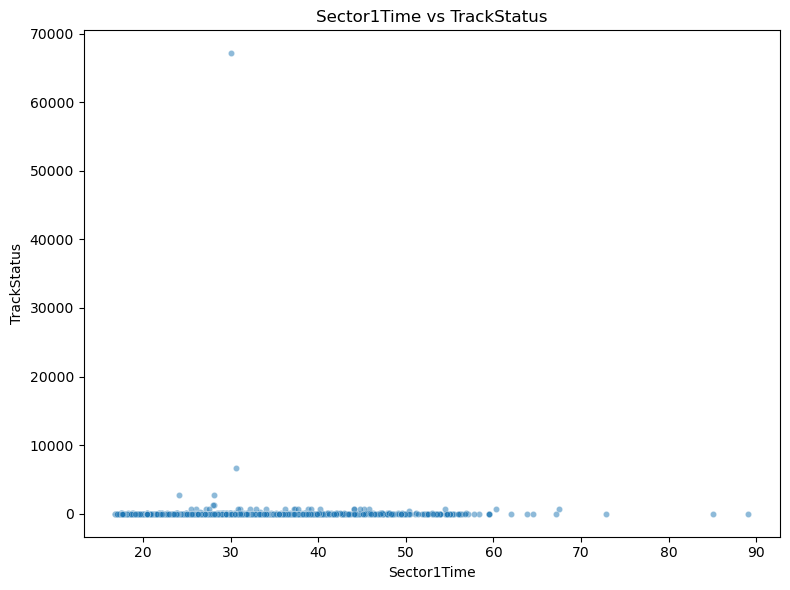

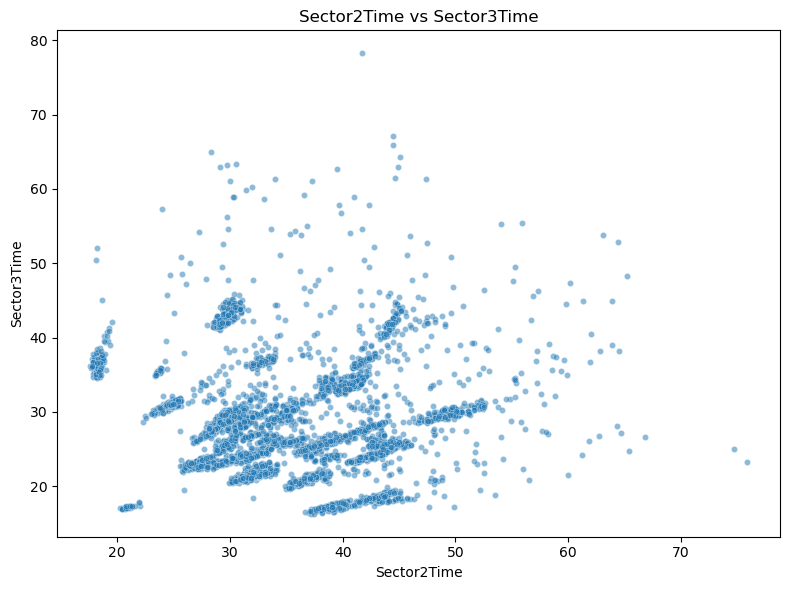

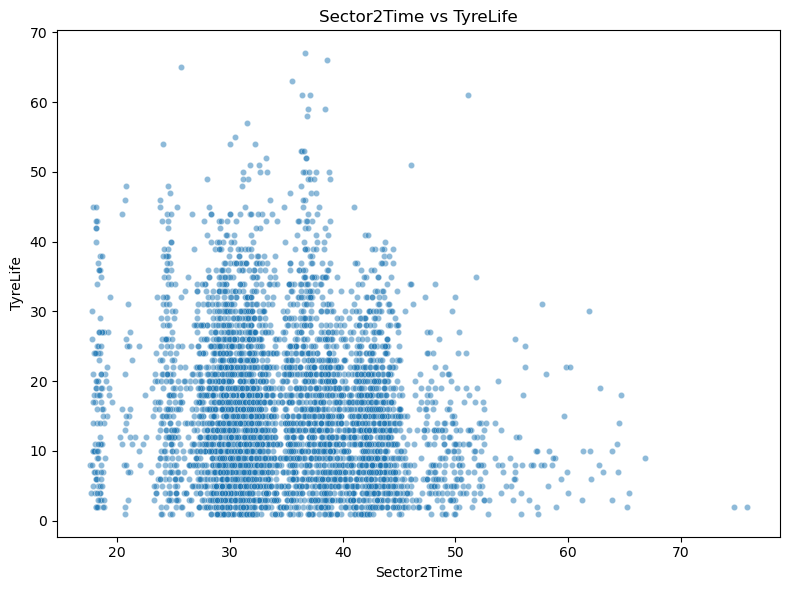

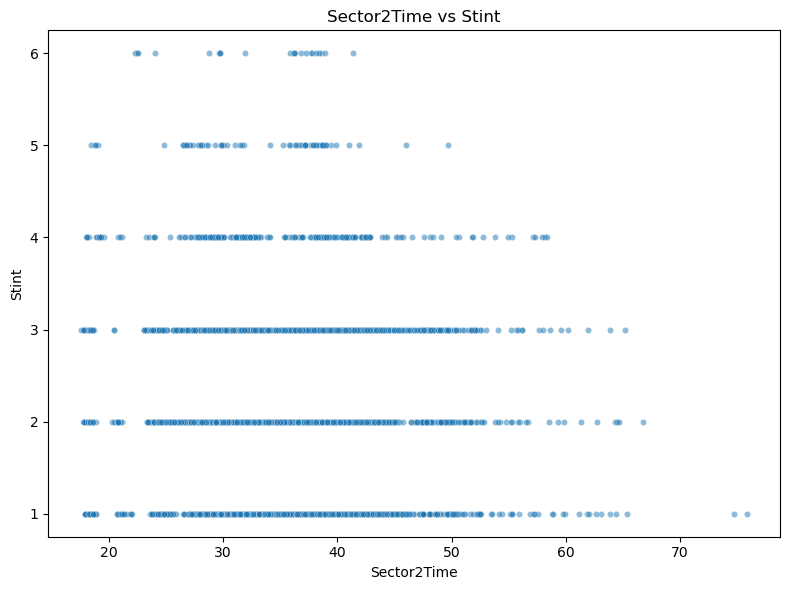

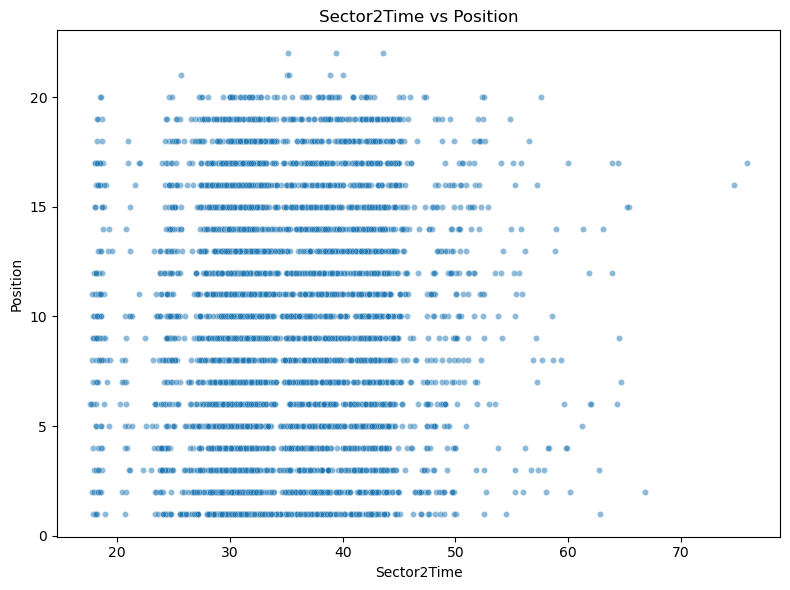

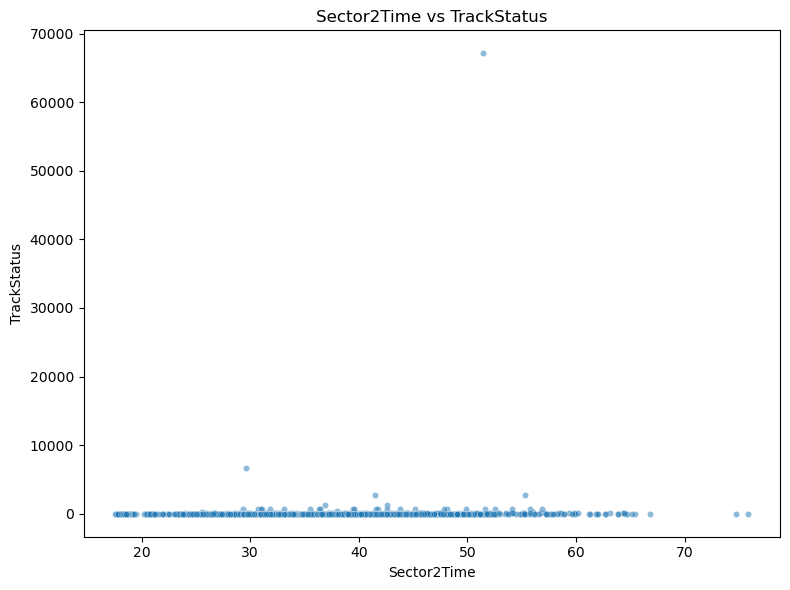

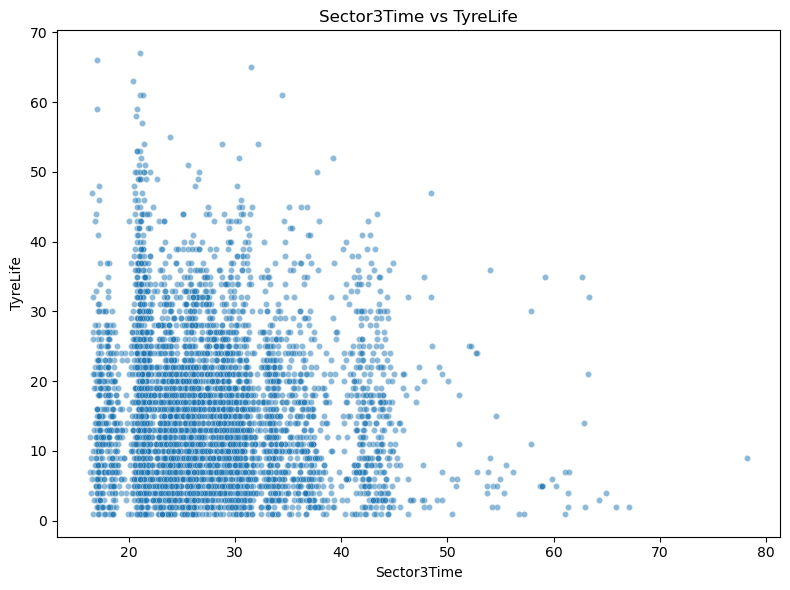

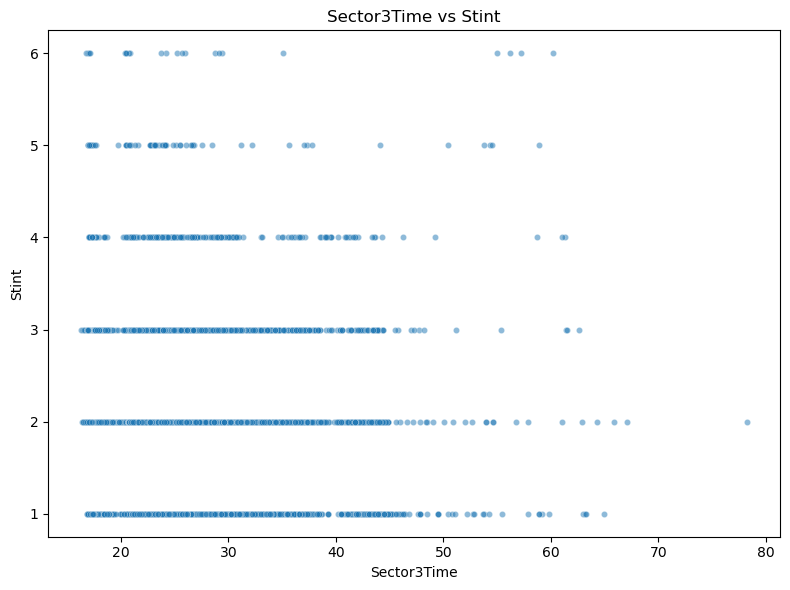

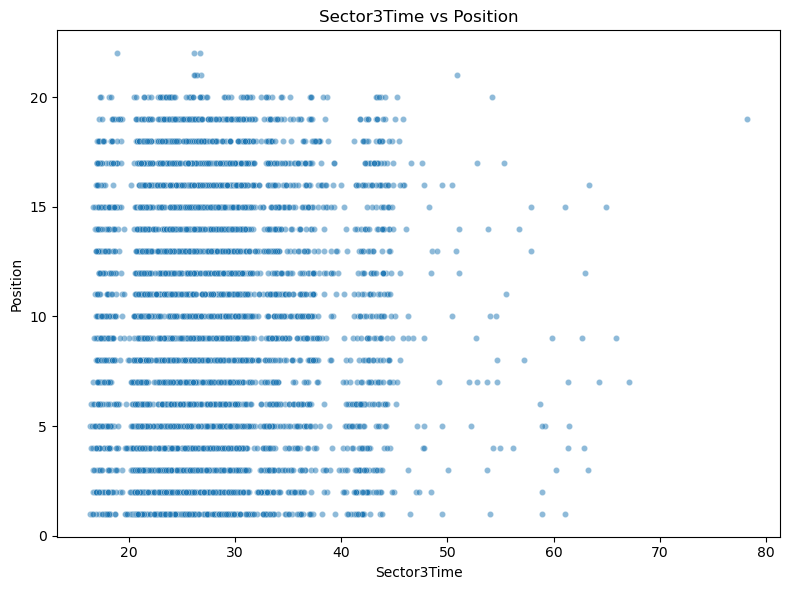

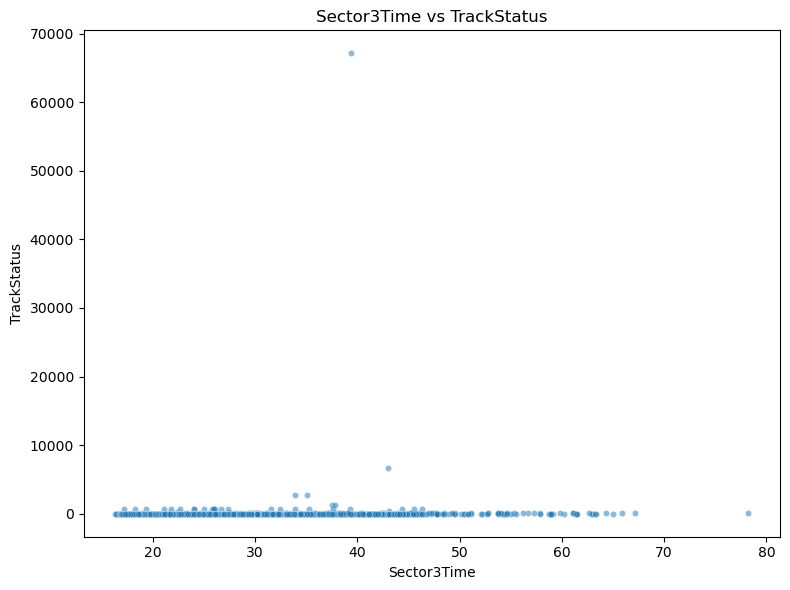

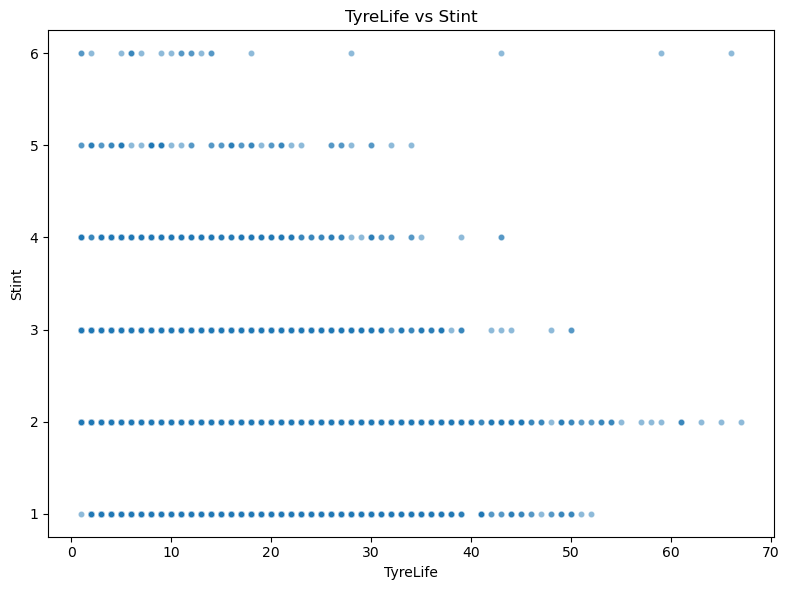

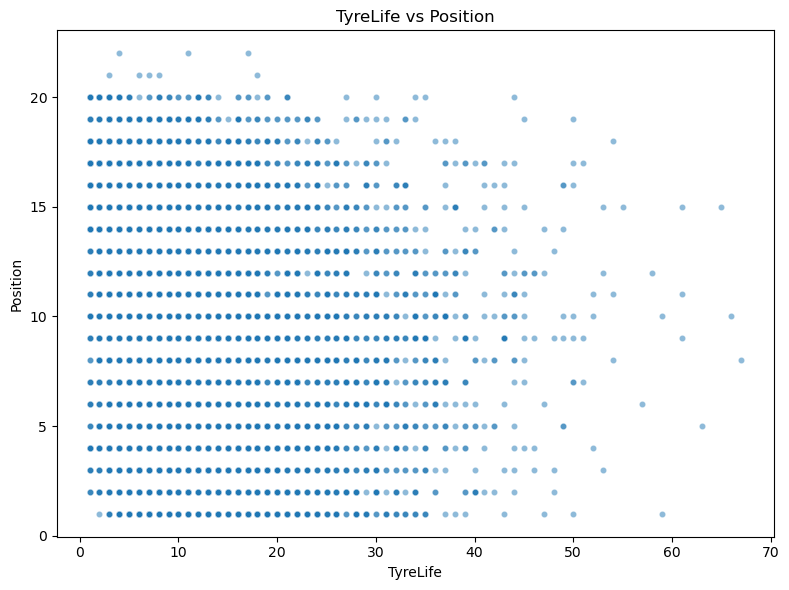

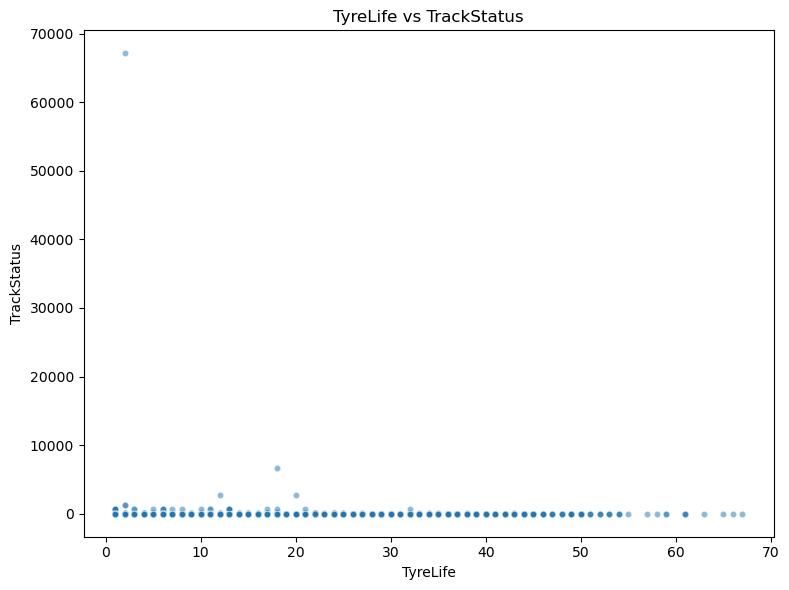

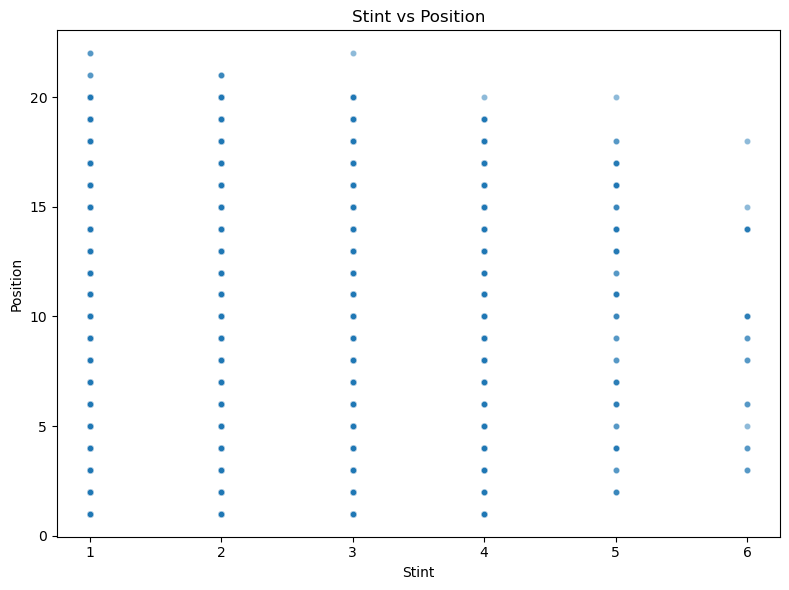

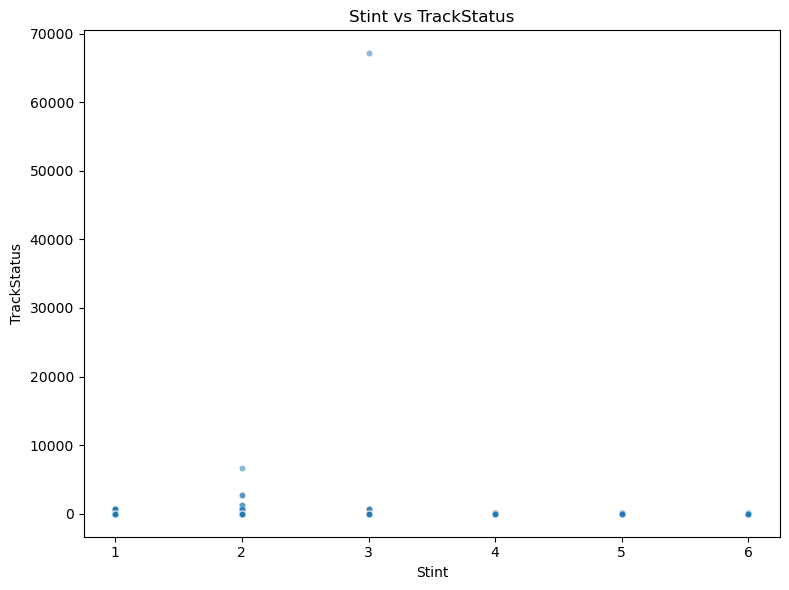

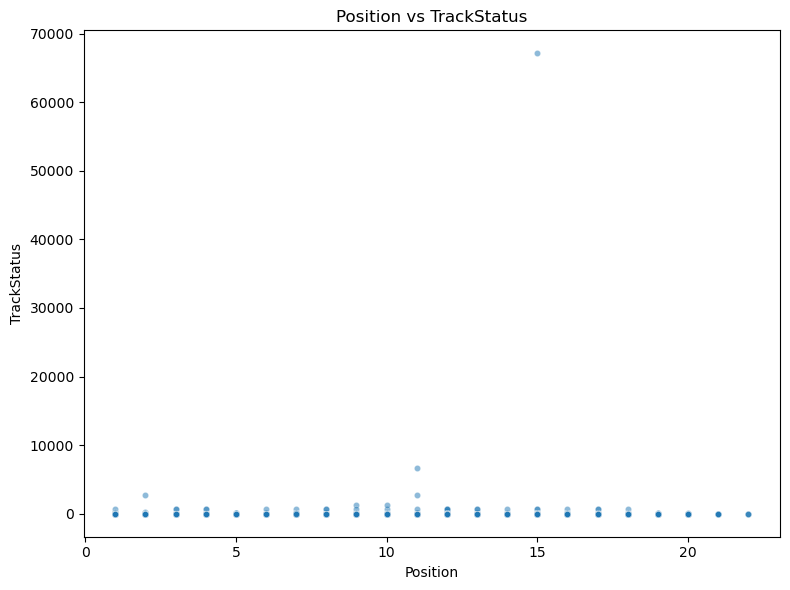

In [11]:
sample_df = df.sample(5000, random_state=42)

import os
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("images/scatterplots", exist_ok=True)

for x, y in itertools.combinations(numerical_cols, 2):

    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        data=sample_df,
        x=x,
        y=y,
        alpha=0.5,
        s=20
    )

    plt.title(f"{x} vs {y}")

    plt.tight_layout()

    plt.savefig(
        f"images/scatterplots/{x}_vs_{y}.png",
        dpi=300
    )

    plt.show()

    plt.close()